# BMDS2003 Data Science — RDS2S1G2 Group 1
## Estimation of Obesity Levels Based on Eating Habits and Physical Condition

**CRISP-DM Framework Implementation**

This notebook applies the Cross Industry Standard Process for Data Mining (CRISP-DM) to the
UCI *Estimation of Obesity Levels* dataset. Four classification models are trained to predict a
person's obesity category from lifestyle, eating-habit, and physical-condition attributes:

| Model | Role | Owner |
|---|---|---|
| Decision Tree | Baseline model | Kyra Aerin Leong |
| Random Forest | Model 2 | Low Li Ping |
| Support Vector Machine (SVM) | Model 3 | Wong Wen Hsuan |
| K-Nearest Neighbours (KNN) | Model 4 | Gladys Lee |

## 1. Import Libraries

In [ ]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import json
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
N_FOLDS = 5  # number of cross-validation folds used consistently across all 4 models

print("Libraries imported successfully.")
print("Random seed fixed at:", RANDOM_STATE)
print("Cross-validation folds (N):", N_FOLDS)

Libraries imported successfully.
Random seed fixed at: 42
Cross-validation folds (N): 5


## 2. Data Understanding

In [ ]:
# ============================================================
# 2. DATA UNDERSTANDING
# ============================================================

# Load the original dataset
obesity = pd.read_csv("obesity.csv")

# ------------------------------------------------------------
# 2.1 Preview the dataset
# ------------------------------------------------------------

print("First five rows:")
display(obesity.head())

print("\nLast five rows:")
display(obesity.tail())

# ------------------------------------------------------------
# 2.2 Check dataset dimensions
# ------------------------------------------------------------

print("Number of rows:", obesity.shape[0])
print("Number of columns:", obesity.shape[1])

# ------------------------------------------------------------
# 2.3 Examine dataset structure
# ------------------------------------------------------------

print("\nDataset information:")
obesity.info()

# ------------------------------------------------------------
# 2.4 Display column names
# ------------------------------------------------------------

print("\nColumn names:")
print(obesity.columns.tolist())

# ------------------------------------------------------------
# 2.5 Identify numerical and categorical columns
# ------------------------------------------------------------

numerical_cols = obesity.select_dtypes(include=np.number).columns.tolist()
categorical_cols = obesity.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

# ------------------------------------------------------------
# 2.6 Summary statistics for numerical variables
# ------------------------------------------------------------

print("\nNumerical summary statistics:")
display(obesity[numerical_cols].describe().T)

# ------------------------------------------------------------
# 2.7 Summary statistics for categorical variables
# ------------------------------------------------------------

print("\nCategorical summary statistics:")
display(obesity[categorical_cols].describe().T)

# ------------------------------------------------------------
# 2.8 Count unique values in every column
# ------------------------------------------------------------

unique_counts = obesity.nunique().sort_values()

print("\nNumber of unique values in each column:")
display(unique_counts.to_frame(name="Unique_Values"))

# ------------------------------------------------------------
# 2.9 Display categories in each categorical column
# ------------------------------------------------------------

print("\nUnique categories in categorical variables:")

for col in categorical_cols:
    print(f"\n{col}:")
    print(obesity[col].unique())

# ------------------------------------------------------------
# 2.10 Examine target-variable distribution
# ------------------------------------------------------------

target_counts = obesity["NObeyesdad"].value_counts()

target_percentages = (
    obesity["NObeyesdad"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

print("\nObesity-level distribution:")
display(target_summary)

First five rows:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Last five rows:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III
2110,Female,23.664709,1.738836,133.472641,yes,yes,3.0,3.0,Sometimes,no,2.863513,no,1.026452,0.714137,Sometimes,Public_Transportation,Obesity_Type_III


Number of rows: 2111
Number of columns: 17

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                           

...

,count,unique,top,freq
Gender,2111,2,Male,1068
family_history_with_overweight,2111,2,yes,1726
FAVC,2111,2,yes,1866
CAEC,2111,4,Sometimes,1765
SMOKE,2111,2,no,2067
SCC,2111,2,no,2015
CALC,2111,4,Sometimes,1401
MTRANS,2111,5,Public_Transportation,1580
NObeyesdad,2111,7,Obesity_Type_I,351



Number of unique values in each column:


,Unique_Values
Gender,2
family_history_with_overweight,2
FAVC,2
SMOKE,2
SCC,2
CAEC,4
CALC,4
MTRANS,5
NObeyesdad,7
NCP,635



Unique categories in categorical variables:

Gender:
['Female' 'Male']

family_history_with_overweight:
['yes' 'no']

FAVC:
['no' 'yes']

CAEC:
['Sometimes' 'Frequently' 'Always' 'no']

SMOKE:
['no' 'yes']

SCC:
['no' 'yes']

CALC:
['no' 'Sometimes' 'Frequently' 'Always']

MTRANS:
['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']

NObeyesdad:
['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']

Obesity-level distribution:


,Count,Percentage
NObeyesdad,,
Obesity_Type_I,351,16.63
Obesity_Type_III,324,15.35
Obesity_Type_II,297,14.07
Overweight_Level_I,290,13.74
Overweight_Level_II,290,13.74
Normal_Weight,287,13.60
Insufficient_Weight,272,12.88


**Short interpretation:** The dataset has 2,111 records and 17 columns (16 predictors + 1
target, `NObeyesdad`). There are 8 numeric columns and 9 categorical/text columns, no missing
values are visible at a glance (confirmed formally in Data Preparation), and the target has
**7 classes** that are reasonably — but not perfectly — balanced (`Obesity_Type_I` is the largest
class, `Insufficient_Weight` and `Obesity_Type_II`/`III` are somewhat smaller). This means
**stratified sampling** and **weighted evaluation metrics** will be needed later.

## 3. Data Preparation

In [ ]:
# ============================================================
# 3. DATA PREPARATION
# ============================================================

# Create a copy so that the original dataset remains unchanged
obesity_cleaned = obesity.copy()

# ------------------------------------------------------------
# 3.1 Check missing values
# ------------------------------------------------------------

missing_summary = pd.DataFrame({
   "Missing_Count": obesity_cleaned.isnull().sum(),
   "Missing_Percentage": (
       obesity_cleaned.isnull().mean() * 100
   ).round(2)
})

print("Missing-value summary:")
display(missing_summary)

print(
   "Total missing values:",
   obesity_cleaned.isnull().sum().sum()
)

Missing-value summary:


,Missing_Count,Missing_Percentage
Gender,0,0.0
Age,0,0.0
Height,0,0.0
Weight,0,0.0
family_history_with_overweight,0,0.0
FAVC,0,0.0
FCVC,0,0.0
NCP,0,0.0
CAEC,0,0.0
SMOKE,0,0.0


Total missing values: 0


In [ ]:
# ------------------------------------------------------------
# 3.2 Rename columns ("rename factors") for readability
# ------------------------------------------------------------
# The raw dataset uses short/abbreviated survey codes (e.g. FCVC, NCP, CH2O).
# We rename them to descriptive, self-explanatory names so that every table,
# plot legend, and model report is readable without a data dictionary.

rename_map = {
    "NObeyesdad": "Obesity_Level",
    "family_history_with_overweight": "Family_History_Overweight",
    "FAVC": "Frequent_High_Caloric_Food",
    "FCVC": "Vegetable_Consumption_Freq",
    "NCP": "Main_Meals_Per_Day",
    "CAEC": "Food_Between_Meals",
    "SMOKE": "Smokes",
    "CH2O": "Daily_Water_Intake",
    "SCC": "Calorie_Monitoring",
    "FAF": "Physical_Activity_Freq",
    "TUE": "Technology_Usage_Time",
    "CALC": "Alcohol_Consumption",
    "MTRANS": "Transportation_Mode",
}

obesity_cleaned.rename(columns=rename_map, inplace=True)

print("Updated column names:")
print(obesity_cleaned.columns.tolist())

Updated column names:
['Gender', 'Age', 'Height', 'Weight', 'Family_History_Overweight', 'Frequent_High_Caloric_Food', 'Vegetable_Consumption_Freq', 'Main_Meals_Per_Day', 'Food_Between_Meals', 'Smokes', 'Daily_Water_Intake', 'Calorie_Monitoring', 'Physical_Activity_Freq', 'Technology_Usage_Time', 'Alcohol_Consumption', 'Transportation_Mode', 'Obesity_Level']


In [ ]:
# ------------------------------------------------------------
# 3.3 Check and remove duplicate records
# ------------------------------------------------------------

duplicate_count = obesity_cleaned.duplicated().sum()

print("Duplicate records before removal:", duplicate_count)
print("Shape before duplicate removal:", obesity_cleaned.shape)

obesity_cleaned.drop_duplicates(inplace=True)

# Reset the index after removing duplicate rows
obesity_cleaned.reset_index(drop=True, inplace=True)

print("Shape after duplicate removal:", obesity_cleaned.shape)
print(
   "Remaining duplicate records:",
   obesity_cleaned.duplicated().sum()
)

Duplicate records before removal: 24
Shape before duplicate removal: (2111, 17)
Shape after duplicate removal: (2087, 17)
Remaining duplicate records: 0


In [ ]:
# ------------------------------------------------------------
# 3.4 Standardise categorical text formats
# ------------------------------------------------------------

categorical_cols_cleaned = obesity_cleaned.select_dtypes(exclude=np.number).columns

# Remove accidental leading/trailing spaces from text values
for col in categorical_cols_cleaned:
    obesity_cleaned[col] = obesity_cleaned[col].astype(str).str.strip()

print("Categorical text values were checked and trimmed.")

pd.set_option("display.float_format", "{:.2f}".format)

Categorical text values were checked and trimmed.


In [ ]:
# ------------------------------------------------------------
# 3.5 Check for impossible or invalid numerical values
# ------------------------------------------------------------

numeric_range_summary = pd.DataFrame({
   "Minimum": obesity_cleaned.select_dtypes(include=np.number).min(),
   "Maximum": obesity_cleaned.select_dtypes(include=np.number).max()
})

print("Numerical value ranges:")
display(numeric_range_summary)

# Logical validity checks
invalid_height = obesity_cleaned[obesity_cleaned["Height"] <= 0]
invalid_weight = obesity_cleaned[obesity_cleaned["Weight"] <= 0]
invalid_age = obesity_cleaned[obesity_cleaned["Age"] <= 0]

print("Invalid Age values:", len(invalid_age))
print("Invalid Height values:", len(invalid_height))
print("Invalid Weight values:", len(invalid_weight))

Numerical value ranges:


,Minimum,Maximum
Age,14.00,61.00
Height,1.45,1.98
Weight,39.00,173.00
Vegetable_Consumption_Freq,1.00,3.00
Main_Meals_Per_Day,1.00,4.00
Daily_Water_Intake,1.00,3.00
Physical_Activity_Freq,0.00,3.00
Technology_Usage_Time,0.00,2.00


Invalid Age values: 0
Invalid Height values: 0
Invalid Weight values: 0


In [ ]:
# ------------------------------------------------------------
# 3.6 Outlier detection — IQR method
# ------------------------------------------------------------

continuous_outlier_columns = ["Age", "Height", "Weight"]

def detect_outliers_iqr(df, columns):
    summary = []
    flags = pd.DataFrame(index=df.index)
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (df[col] < lower) | (df[col] > upper)
        flags[col] = mask
        summary.append({
            "Variable": col, "Lower_Bound": round(lower, 2), "Upper_Bound": round(upper, 2),
            "Outlier_Count": int(mask.sum()), "Outlier_Percentage": round(mask.mean() * 100, 2)
        })
    return pd.DataFrame(summary), flags

iqr_summary, iqr_flags = detect_outliers_iqr(obesity_cleaned, continuous_outlier_columns)
print("IQR outlier summary:")
display(iqr_summary)

IQR outlier summary:


,Variable,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,Age,10.79,35.13,167,8.00
1,Height,1.42,1.98,1,0.05
2,Weight,2.98,171.04,1,0.05


In [ ]:
# ------------------------------------------------------------
# 3.7 Outlier detection — Z-score method
# ------------------------------------------------------------
# Flags values more than 3 standard deviations from the mean.

def detect_outliers_zscore(df, columns, threshold=3):
    summary = []
    flags = pd.DataFrame(index=df.index)
    for col in columns:
        mean = df[col].mean()
        std = df[col].std()
        z_scores = (df[col] - mean) / std
        mask = z_scores.abs() > threshold
        flags[col] = mask
        summary.append({
            "Variable": col, "Mean": round(mean, 2), "Std_Dev": round(std, 2),
            "Threshold": threshold, "Outlier_Count": int(mask.sum()),
            "Outlier_Percentage": round(mask.mean() * 100, 2)
        })
    return pd.DataFrame(summary), flags

zscore_summary, zscore_flags = detect_outliers_zscore(obesity_cleaned, continuous_outlier_columns)
print("Z-score outlier summary (|z| > 3):")
display(zscore_summary)

Z-score outlier summary (|z| > 3):


,Variable,Mean,Std_Dev,Threshold,Outlier_Count,Outlier_Percentage
0,Age,24.35,6.37,3,23,1.10
1,Height,1.70,0.09,3,0,0.00
2,Weight,86.86,26.19,3,1,0.05


In [ ]:
# ------------------------------------------------------------
# 3.8 Outlier detection — Modified Z-score method
# ------------------------------------------------------------
# Uses the median and Median Absolute Deviation (MAD), which is more robust
# to skewed distributions than the mean/std used by the standard Z-score.

def detect_outliers_modified_zscore(df, columns, threshold=3.5):
    summary = []
    flags = pd.DataFrame(index=df.index)
    for col in columns:
        median = df[col].median()
        mad = (df[col] - median).abs().median()
        # 0.6745 scales the MAD to be comparable with the standard deviation
        modified_z = 0.6745 * (df[col] - median) / (mad if mad != 0 else 1e-9)
        mask = modified_z.abs() > threshold
        flags[col] = mask
        summary.append({
            "Variable": col, "Median": round(median, 2), "MAD": round(mad, 2),
            "Threshold": threshold, "Outlier_Count": int(mask.sum()),
            "Outlier_Percentage": round(mask.mean() * 100, 2)
        })
    return pd.DataFrame(summary), flags

modz_summary, modz_flags = detect_outliers_modified_zscore(obesity_cleaned, continuous_outlier_columns)
print("Modified Z-score outlier summary (|M| > 3.5):")
display(modz_summary)

# ------------------------------------------------------------
# Combined comparison of the three outlier-detection methods
# ------------------------------------------------------------

outlier_method_comparison = pd.DataFrame({
    "IQR_Outliers": iqr_summary.set_index("Variable")["Outlier_Count"],
    "Zscore_Outliers": zscore_summary.set_index("Variable")["Outlier_Count"],
    "ModifiedZ_Outliers": modz_summary.set_index("Variable")["Outlier_Count"],
})
print("\nComparison of outlier counts across methods:")
display(outlier_method_comparison)

Modified Z-score outlier summary (|M| > 3.5):


,Variable,Median,MAD,Threshold,Outlier_Count,Outlier_Percentage
0,Age,22.85,3.15,3.50,75,3.59
1,Height,1.70,0.07,3.50,0,0.00
2,Weight,83.10,21.67,3.50,0,0.00



Comparison of outlier counts across methods:


,IQR_Outliers,Zscore_Outliers,ModifiedZ_Outliers
Variable,,,
Age,167,23,75
Height,1,0,0
Weight,1,1,0


**Short interpretation:** All three methods (IQR, Z-score, Modified Z-score) agree that only
a small number of `Age` records are flagged as outliers (a few respondents in their 40s–60s in a
mostly young-adult sample); `Height` and `Weight` show almost no outliers. Because these values are
physiologically plausible (a 50-year-old or a 170 kg adult are real possibilities, not data-entry
errors), **we retain all records** rather than deleting them — removing them would shrink the
already smaller obesity classes (`Obesity_Type_II`/`III`) and bias the model. This decision is
documented here and repeated in the report's Data Preparation section.

In [ ]:
# ------------------------------------------------------------
# 3.9 Feature engineering — Body Mass Index (BMI)
# ------------------------------------------------------------
# BMI = Weight (kg) / Height (m)^2 is the clinical standard used to define
# obesity categories, and is a useful variable for EXPLORATORY analysis and
# for sanity-checking the target labels. It is intentionally EXCLUDED from
# the machine-learning feature set in Section 6 because it is a deterministic
# function of Height and Weight (which are already features) — including it
# would let the model trivially "look up" the answer instead of learning
# genuine lifestyle patterns.

obesity_cleaned["BMI"] = (
    obesity_cleaned["Weight"] / (obesity_cleaned["Height"] ** 2)
).round(2)

# ------------------------------------------------------------
# 3.10 Categorisation — Equal-width and Equal-frequency binning of Age
# ------------------------------------------------------------
# Demonstrates two standard categorisation/discretisation techniques.

obesity_cleaned["Age_Group_EqualWidth"] = pd.cut(
    obesity_cleaned["Age"], bins=4,
    labels=["Youngest", "Young_Adult", "Adult", "Older_Adult"]
)

obesity_cleaned["Age_Group_EqualFreq"] = pd.qcut(
    obesity_cleaned["Age"], q=4,
    labels=["Q1_Youngest", "Q2", "Q3", "Q4_Oldest"]
)

print("Equal-width Age bins (roughly equal RANGE per bin):")
display(obesity_cleaned["Age_Group_EqualWidth"].value_counts().sort_index())

print("\nEqual-frequency Age bins (roughly equal COUNT per bin):")
display(obesity_cleaned["Age_Group_EqualFreq"].value_counts().sort_index())

# Age_Group_EqualWidth is used later in EDA (Section 5); both engineered
# columns (BMI, Age_Group_*) are excluded from ML training features in
# Section 6 to avoid leakage / redundancy.
obesity_cleaned.rename(columns={"Age_Group_EqualWidth": "Age_Group"}, inplace=True)
obesity_cleaned.drop(columns=["Age_Group_EqualFreq"], inplace=True)

Equal-width Age bins (roughly equal RANGE per bin):


,count
Age_Group_EqualWidth,
Youngest,1417
Young_Adult,540
Adult,120
Older_Adult,10



Equal-frequency Age bins (roughly equal COUNT per bin):


,count
Age_Group_EqualFreq,
Q1_Youngest,522
Q2,522
Q3,545
Q4_Oldest,498


In [ ]:
# ------------------------------------------------------------
# 3.11 Standardisation demonstration — Min-Max, Z-score, Decimal scaling
# ------------------------------------------------------------
# Demonstrated here on the "Weight" column for teaching purposes. The actual
# scaling used inside the ML pipelines (Section 6) is StandardScaler
# (Z-score), applied only to the training data to avoid data leakage.

demo_col = obesity_cleaned["Weight"]

# Min-Max scaling -> rescales to [0, 1]
minmax_scaled = (demo_col - demo_col.min()) / (demo_col.max() - demo_col.min())

# Z-score standardisation -> mean 0, standard deviation 1
zscore_scaled = (demo_col - demo_col.mean()) / demo_col.std()

# Decimal scaling -> divide by 10^k so the maximum absolute value < 1
k = len(str(int(demo_col.abs().max())))
decimal_scaled = demo_col / (10 ** k)

standardisation_demo = pd.DataFrame({
    "Original_Weight": demo_col,
    "MinMax_Scaled": minmax_scaled.round(4),
    "Zscore_Scaled": zscore_scaled.round(4),
    "Decimal_Scaled": decimal_scaled.round(4),
}).head(10)

print("Standardisation technique comparison (first 10 rows, 'Weight' column):")
display(standardisation_demo)

Standardisation technique comparison (first 10 rows, 'Weight' column):


,Original_Weight,MinMax_Scaled,Zscore_Scaled,Decimal_Scaled
0,64.00,0.19,-0.87,0.06
1,56.00,0.13,-1.18,0.06
2,77.00,0.28,-0.38,0.08
3,87.00,0.36,0.01,0.09
4,89.80,0.38,0.11,0.09
5,53.00,0.10,-1.29,0.05
6,55.00,0.12,-1.22,0.06
7,53.00,0.10,-1.29,0.05
8,64.00,0.19,-0.87,0.06
9,68.00,0.22,-0.72,0.07


In [ ]:
# ------------------------------------------------------------
# 3.12 Final validation of the cleaned dataset
# ------------------------------------------------------------

print("Final cleaned dataset shape:", obesity_cleaned.shape)
print("Total missing values after cleaning:", obesity_cleaned.isnull().sum().sum())
print("Remaining duplicates after cleaning:", obesity_cleaned.duplicated().sum())

print("\nCleaned dataset information:")
obesity_cleaned.info()

print("\nFirst five rows of the cleaned dataset:")
display(obesity_cleaned.head())

# ------------------------------------------------------------
# 3.13 Save the cleaned dataset
# ------------------------------------------------------------

obesity_cleaned.to_csv("obesity_cleaned.csv", index=False)
print("\nCleaned dataset saved as 'obesity_cleaned.csv'.")

Final cleaned dataset shape: (2087, 19)
Total missing values after cleaning: 0
Remaining duplicates after cleaning: 0

Cleaned dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2087 entries, 0 to 2086
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Gender                      2087 non-null   object  
 1   Age                         2087 non-null   float64 
 2   Height                      2087 non-null   float64 
 3   Weight                      2087 non-null   float64 
 4   Family_History_Overweight   2087 non-null   object  
 5   Frequent_High_Caloric_Food  2087 non-null   object  
 6   Vegetable_Consumption_Freq  2087 non-null   float64 
 7   Main_Meals_Per_Day          2087 non-null   float64 
 8   Food_Between_Meals          2087 non-null   object  
 9   Smokes                      2087 non-null   object  
 10  Daily_Water_Intake          2087 non-null   

,Gender,Age,Height,Weight,Family_History_Overweight,Frequent_High_Caloric_Food,Vegetable_Consumption_Freq,Main_Meals_Per_Day,Food_Between_Meals,Smokes,Daily_Water_Intake,Calorie_Monitoring,Physical_Activity_Freq,Technology_Usage_Time,Alcohol_Consumption,Transportation_Mode,Obesity_Level,BMI,Age_Group
0,Female,21.00,1.62,64.00,yes,no,2.00,3.00,Sometimes,no,2.00,no,0.00,1.00,no,Public_Transportation,Normal_Weight,24.39,Youngest
1,Female,21.00,1.52,56.00,yes,no,3.00,3.00,Sometimes,yes,3.00,yes,3.00,0.00,Sometimes,Public_Transportation,Normal_Weight,24.24,Youngest
2,Male,23.00,1.80,77.00,yes,no,2.00,3.00,Sometimes,no,2.00,no,2.00,1.00,Frequently,Public_Transportation,Normal_Weight,23.77,Youngest
3,Male,27.00,1.80,87.00,no,no,3.00,3.00,Sometimes,no,2.00,no,2.00,0.00,Frequently,Walking,Overweight_Level_I,26.85,Young_Adult
4,Male,22.00,1.78,89.80,no,no,2.00,1.00,Sometimes,no,2.00,no,0.00,0.00,Sometimes,Public_Transportation,Overweight_Level_II,28.34,Youngest



Cleaned dataset saved as 'obesity_cleaned.csv'.


**Short interpretation:** Data preparation involved (1) renaming abbreviated columns for
readability, (2) confirming there are no missing values or duplicate rows, (3) validating that
`Age`, `Height`, `Weight` contain no impossible values, (4) checking for outliers with three
complementary methods and deciding to retain all records, and (5) engineering two EDA-only
columns — `BMI` and `Age_Group` — that are excluded from model training. The cleaned dataset
(2,087 rows after de-duplication) is saved as `obesity_cleaned.csv` and re-used for the rest of the
notebook and for the Streamlit app's Data Exploration tab.

## 4. Descriptive Data Analysis

In [ ]:
# ============================================================
# 4. DESCRIPTIVE DATA ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 4.1 Numerical summary statistics
# ------------------------------------------------------------

numerical_summary = obesity_cleaned.describe().T
display(numerical_summary)

# ------------------------------------------------------------
# 4.2 Categorical summary statistics
# ------------------------------------------------------------

categorical_summary = obesity_cleaned.select_dtypes(exclude=np.number).describe().T
display(categorical_summary)

# ------------------------------------------------------------
# 4.3 Obesity-level frequency table
# ------------------------------------------------------------

obesity_level_frequency = pd.DataFrame({
    "Count": obesity_cleaned["Obesity_Level"].value_counts(),
    "Percentage": (
        obesity_cleaned["Obesity_Level"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

display(obesity_level_frequency)

,count,mean,std,min,25%,50%,75%,max
Age,2087.00,24.35,6.37,14.00,19.92,22.85,26.00,61.00
Height,2087.00,1.70,0.09,1.45,1.63,1.70,1.77,1.98
Weight,2087.00,86.86,26.19,39.00,66.00,83.10,108.02,173.00
Vegetable_Consumption_Freq,2087.00,2.42,0.53,1.00,2.00,2.40,3.00,3.00
Main_Meals_Per_Day,2087.00,2.70,0.76,1.00,2.70,3.00,3.00,4.00
Daily_Water_Intake,2087.00,2.00,0.61,1.00,1.59,2.00,2.47,3.00
Physical_Activity_Freq,2087.00,1.01,0.85,0.00,0.12,1.00,1.68,3.00
Technology_Usage_Time,2087.00,0.66,0.61,0.00,0.00,0.63,1.00,2.00
BMI,2087.00,29.77,8.02,13.00,24.37,28.90,36.09,50.81


,count,unique,top,freq
Gender,2087,2,Male,1052
Family_History_Overweight,2087,2,yes,1722
Frequent_High_Caloric_Food,2087,2,yes,1844
Food_Between_Meals,2087,4,Sometimes,1761
Smokes,2087,2,no,2043
Calorie_Monitoring,2087,2,no,1991
Alcohol_Consumption,2087,4,Sometimes,1380
Transportation_Mode,2087,5,Public_Transportation,1558
Obesity_Level,2087,7,Obesity_Type_I,351
Age_Group,2087,4,Youngest,1417


,Count,Percentage
Obesity_Level,,
Obesity_Type_I,351,16.82
Obesity_Type_III,324,15.52
Obesity_Type_II,297,14.23
Overweight_Level_II,290,13.90
Normal_Weight,282,13.51
Overweight_Level_I,276,13.22
Insufficient_Weight,267,12.79


In [ ]:
# ------------------------------------------------------------
# 4.4 Gender frequency table
# ------------------------------------------------------------

gender_frequency = pd.DataFrame({
    "Count": obesity_cleaned["Gender"].value_counts(),
    "Percentage": (
        obesity_cleaned["Gender"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

display(gender_frequency)

# ------------------------------------------------------------
# 4.5 Family-history frequency table
# ------------------------------------------------------------

family_history_frequency = pd.DataFrame({
    "Count": obesity_cleaned["Family_History_Overweight"].value_counts(),
    "Percentage": (
        obesity_cleaned["Family_History_Overweight"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

display(family_history_frequency)

# ------------------------------------------------------------
# 4.6 Transport frequency table
# ------------------------------------------------------------

transport_frequency = pd.DataFrame({
    "Count": obesity_cleaned["Transportation_Mode"].value_counts(),
    "Percentage": (
        obesity_cleaned["Transportation_Mode"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

display(transport_frequency)

# ------------------------------------------------------------
# 4.7 Other categorical frequency tables
# ------------------------------------------------------------

categorical_columns_for_frequency = [
    "Frequent_High_Caloric_Food",
    "Food_Between_Meals",
    "Smokes",
    "Calorie_Monitoring",
    "Alcohol_Consumption",
]

for col in categorical_columns_for_frequency:
    print(f"\nFrequency table for {col}")
    frequency_table = pd.DataFrame({
        "Count": obesity_cleaned[col].value_counts(),
        "Percentage": (
            obesity_cleaned[col]
            .value_counts(normalize=True)
            .mul(100)
            .round(2)
        )
    })
    display(frequency_table)

,Count,Percentage
Gender,,
Male,1052,50.41
Female,1035,49.59


,Count,Percentage
Family_History_Overweight,,
yes,1722,82.51
no,365,17.49


,Count,Percentage
Transportation_Mode,,
Public_Transportation,1558,74.65
Automobile,456,21.85
Walking,55,2.64
Motorbike,11,0.53
Bike,7,0.34



Frequency table for Frequent_High_Caloric_Food


,Count,Percentage
Frequent_High_Caloric_Food,,
yes,1844,88.36
no,243,11.64


...

,Count,Percentage
Smokes,,
no,2043,97.89
yes,44,2.11



Frequency table for Calorie_Monitoring


,Count,Percentage
Calorie_Monitoring,,
no,1991,95.40
yes,96,4.60



Frequency table for Alcohol_Consumption


,Count,Percentage
Alcohol_Consumption,,
Sometimes,1380,66.12
no,636,30.47
Frequently,70,3.35
Always,1,0.05


**Short interpretation:** The sample is almost evenly split by gender (almost 50/50). Roughly
82% of respondents report a family history of overweight — a strong candidate predictor. Most
respondents (about 88%) frequently eat high-caloric food, very few smoke (about 2%) or actively monitor
calories (about 4.5%), and Public Transportation is by far the most common commute mode. These
imbalances are worth flagging: rare categories (e.g. `Smokes = yes`) will contribute little
statistical signal and their one-hot columns will be sparse.

## 5. Exploratory Data Analysis
The analysis answers concrete questions about the respondents and keeps
the seven obesity labels in clinical order. Charts use readable labels,
fixed units and direct annotations. Plotly charts can be hovered, zoomed
and filtered through their legends. EDA is descriptive: it does not add
`BMI` or `Age_Group` to the modelling predictors and it does not claim
that an association proves causation.

**EDA checklist:** class coverage, distributions, group composition,
numeric relationships, categorical association, conditional patterns,
within-class overlap, and an OLAP-style drill-down.


In [ ]:
# ------------------------------------------------------------
# 5.0 EDA setup and reusable display helpers
# ------------------------------------------------------------
from pathlib import Path
from IPython.display import display, Markdown
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import LabelEncoder # Added this import

# The raw target labels are kept in their clinical order rather than
# being sorted alphabetically or by frequency.
obesity_order = [
    "Insufficient_Weight", "Normal_Weight", "Overweight_Level_I",
    "Overweight_Level_II", "Obesity_Type_I", "Obesity_Type_II",
    "Obesity_Type_III",
]

short_labels = {
    "Insufficient_Weight": "Insufficient",
    "Normal_Weight": "Normal",
    "Overweight_Level_I": "Overweight I",
    "Overweight_Level_II": "Overweight II",
    "Obesity_Type_I": "Obesity I",
    "Obesity_Type_II": "Obesity II",
    "Obesity_Type_III": "Obesity III",
}
obesity_palette = sns.color_palette("YlOrRd", n_colors=len(obesity_order)).as_hex()
obesity_colors = dict(zip(obesity_order, obesity_palette))
severity_rank = {label: i for i, label in enumerate(obesity_order)}
obesity_eda = obesity_cleaned.copy()
obesity_eda["Severity_Rank"] = obesity_eda["Obesity_Level"].map(severity_rank)
eda_outputs = Path("eda_outputs")
eda_outputs.mkdir(exist_ok=True)

def finish_plot(fig, filename):
    fig.tight_layout()
    fig.savefig(eda_outputs / filename, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()

def note(text):
    display(Markdown("**Observation.** " + text))

print(f"EDA dataset: {len(obesity_eda):,} cleaned records")
print("BMI and Age_Group remain EDA-only variables and are excluded in Section 6.")

EDA dataset: 2,087 cleaned records
BMI and Age_Group remain EDA-only variables and are excluded in Section 6.


### 5.1 Class balance and sample coverage

**Question:** Are all seven classes represented at a similar scale? The
count and percentage table provides the denominator for every later
comparison. It describes this dataset and should not be interpreted as
population prevalence.


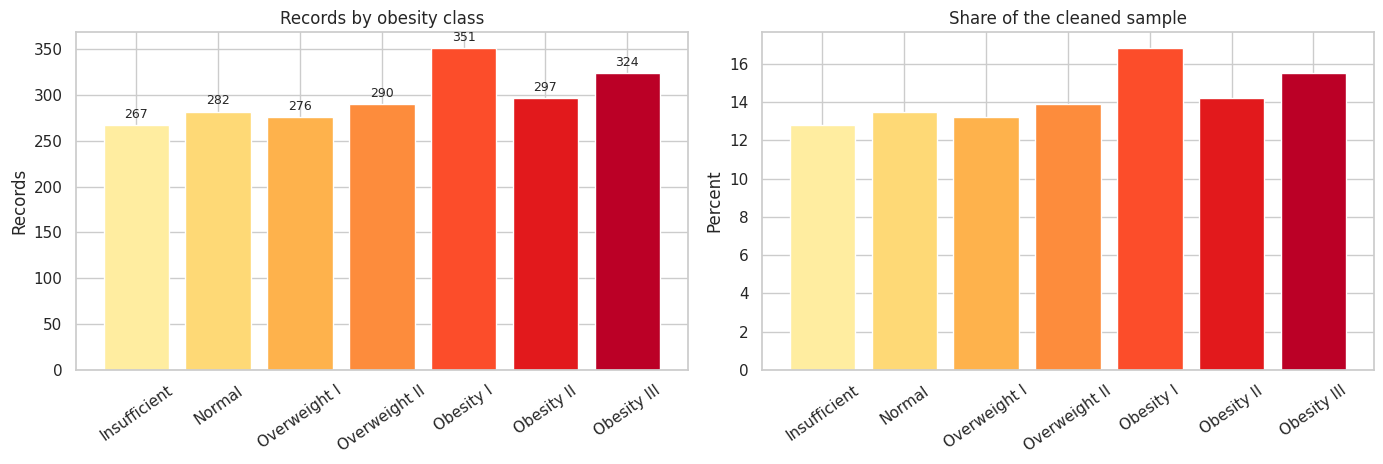

,Records,Share (%)
Obesity_Level,,
Insufficient,267,12.79
Normal,282,13.51
Overweight I,276,13.22
Overweight II,290,13.90
Obesity I,351,16.82
Obesity II,297,14.23
Obesity III,324,15.52


**Observation.** The largest class contains 351 records and the smallest contains 267. Stratification in Section 6 keeps these class proportions similar in the train and test sets.

In [ ]:
class_counts = obesity_eda["Obesity_Level"].value_counts().reindex(obesity_order, fill_value=0)
class_table = pd.DataFrame({"Records": class_counts, "Share (%)": class_counts / len(obesity_eda) * 100})
class_table.index = class_table.index.map(short_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
bars = axes[0].bar(class_table.index, class_table["Records"], color=obesity_palette)
axes[0].bar_label(bars, padding=3, fontsize=9)
axes[0].set_title("Records by obesity class")
axes[0].set_ylabel("Records")
axes[0].tick_params(axis="x", rotation=35)
axes[1].bar(class_table.index, class_table["Share (%)"], color=obesity_palette)
axes[1].set_title("Share of the cleaned sample")
axes[1].set_ylabel("Percent")
axes[1].tick_params(axis="x", rotation=35)
finish_plot(fig, "eda_01_class_balance.png")
display(class_table.round(2))
note(f"The largest class contains {class_counts.max():,} records and the smallest contains {class_counts.min():,}. Stratification in Section 6 keeps these class proportions similar in the train and test sets.")


### 5.2 Numeric distribution dashboard

**Question:** What ranges dominate the sample before comparing classes?
Histograms show the overall shape of age, height and weight. KDE curves
are visual guides only; they do not change the values used for modelling.


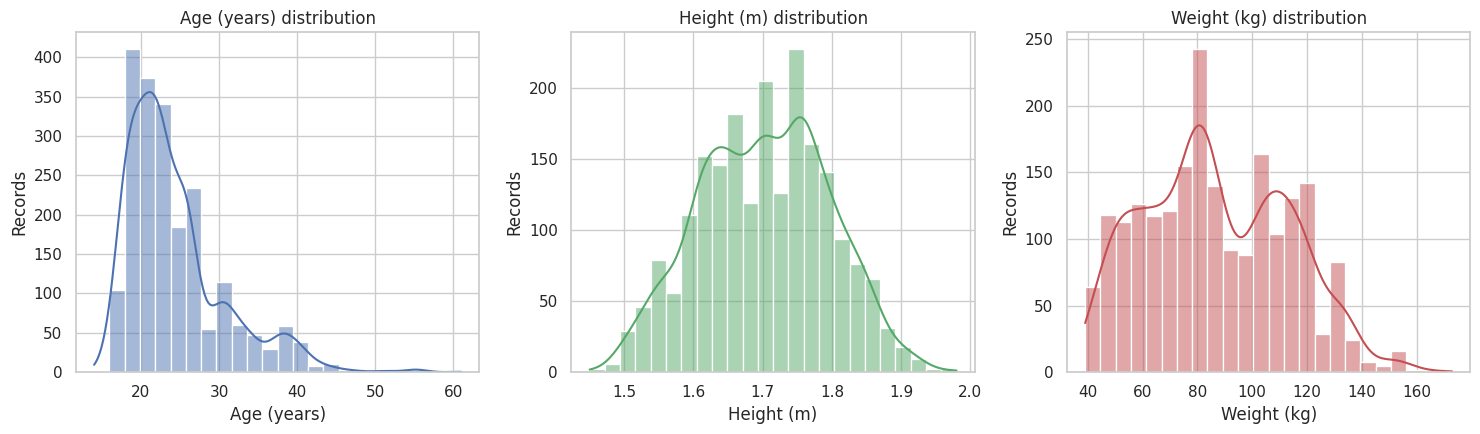

,count,mean,std,min,25%,50%,75%,max
Age,2087.00,24.35,6.37,14.00,19.92,22.85,26.00,61.00
Height,2087.00,1.70,0.09,1.45,1.63,1.70,1.77,1.98
Weight,2087.00,86.86,26.19,39.00,66.00,83.10,108.02,173.00
BMI,2087.00,29.77,8.02,13.00,24.37,28.90,36.10,50.81


**Observation.** The ranges are broad enough to support subgroup comparisons. Height and weight are continuous inputs, while BMI is calculated for interpretation and quality checking.

In [ ]:
numeric_dashboard = [("Age", "Age (years)", "#4C72B0"), ("Height", "Height (m)", "#55A868"), ("Weight", "Weight (kg)", "#C44E52")]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (column, label, colour) in zip(axes, numeric_dashboard):
    sns.histplot(obesity_eda, x=column, bins=24, kde=True, color=colour, ax=ax)
    ax.set_title(f"{label} distribution")
    ax.set_xlabel(label)
    ax.set_ylabel("Records")
finish_plot(fig, "eda_02_numeric_distributions.png")
display(obesity_eda[["Age", "Height", "Weight", "BMI"]].describe().T.round(2))
note("The ranges are broad enough to support subgroup comparisons. Height and weight are continuous inputs, while BMI is calculated for interpretation and quality checking.")


### 5.3 Gender composition across obesity classes
**Question:** Is each obesity class represented by both genders, and are
the class-specific gender proportions similar? This is more informative
than repeating the mechanically increasing BMI medians. Counts are shown
beside a 100% within-class composition chart so unequal class sizes are
not confused with gender differences.

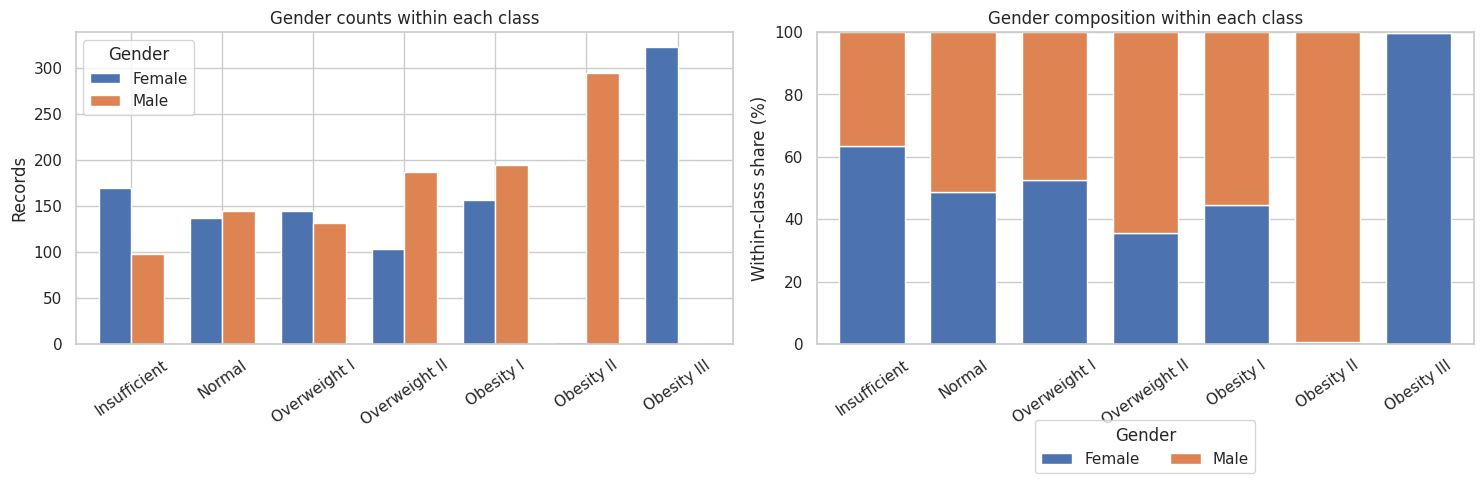

Gender,Female,Male
Obesity_Level,,
Insufficient,169,98
Normal,137,145
Overweight I,145,131
Overweight II,103,187
Obesity I,156,195
Obesity II,2,295
Obesity III,323,1


**Observation.** A class can have a different gender mix even when its total count is small. Read the percentages together with the count panel so sparse groups are not overinterpreted.

In [ ]:
gender_counts = pd.crosstab(obesity_eda["Obesity_Level"], obesity_eda["Gender"]).reindex(obesity_order, fill_value=0)
gender_percentages = gender_counts.div(gender_counts.sum(axis=1), axis=0).mul(100)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
gender_counts.rename(index=short_labels).plot(kind="bar", color=["#4C72B0", "#DD8452"], ax=axes[0], width=0.72)
axes[0].set_title("Gender counts within each class")
axes[0].set_xlabel("")
axes[0].set_ylabel("Records")
axes[0].tick_params(axis="x", rotation=35)
gender_percentages.rename(index=short_labels).plot(kind="bar", stacked=True, color=["#4C72B0", "#DD8452"], ax=axes[1], width=0.72)
axes[1].set_title("Gender composition within each class")
axes[1].set_xlabel("")
axes[1].set_ylabel("Within-class share (%)")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=35)
axes[1].legend(title="Gender", loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2)
fig.subplots_adjust(bottom=0.25)
finish_plot(fig, "eda_03_gender_composition.png")
display(gender_counts.rename(index=short_labels))
note("A class can have a different gender mix even when its total count is small. Read the percentages together with the count panel so sparse groups are not overinterpreted.")


### 5.4 Interactive height–weight map

**Question:** How are body measurements distributed across labels? Hover
over a point for its age, gender, BMI and class. Click a legend entry to
hide a class and zoom into a region. This is a descriptive view; the model
still receives the original height and weight columns.


In [ ]:
height_weight_fig = px.scatter(
    obesity_eda, x="Height", y="Weight", color="Obesity_Level",
    category_orders={"Obesity_Level": obesity_order}, color_discrete_map=obesity_colors,
    hover_data={"Age": ":.1f", "Gender": True, "BMI": ":.2f", "Obesity_Level": True},
    title="Interactive height and weight by obesity class", opacity=0.72,
)
height_weight_fig.update_layout(height=520, legend_title="Obesity class")
height_weight_fig.show()
height_weight_fig.write_html(eda_outputs / "eda_04_height_weight_interactive.html", include_plotlyjs="cdn")
note("The diagonal structure reflects the relationship between height, weight and the BMI-based target construction. Use lifestyle plots below to inspect non-body-measurement patterns.")


**Observation.** The diagonal structure reflects the relationship between height, weight and the BMI-based target construction. Use lifestyle plots below to inspect non-body-measurement patterns.

### 5.5 Interactive BMI–age relationship

**Question:** Does BMI vary with age in the same way for every class?
Marginal histograms reveal where points accumulate, while hover and legend
controls help inspect individual classes.


In [ ]:
bmi_age_fig = px.scatter(
    obesity_eda, x="Age", y="BMI", color="Obesity_Level",
    category_orders={"Obesity_Level": obesity_order}, color_discrete_map=obesity_colors,
    hover_data={"Height": ":.2f", "Weight": ":.1f", "Gender": True},
    title="Interactive BMI and age relationship", opacity=0.68,
)
bmi_age_fig.update_layout(height=520, yaxis_title="BMI (kg/m²)", legend_title="Obesity class")
bmi_age_fig.show()


### 5.6 Correlation heatmap with leakage context

**Question:** Which numeric variables move together? Pearson correlation is
useful for a first linear check, but it is not a causal measure. BMI is
shown for EDA because it is clinically interpretable; it is excluded from
the predictors later because it is deterministically calculated from height
and weight.


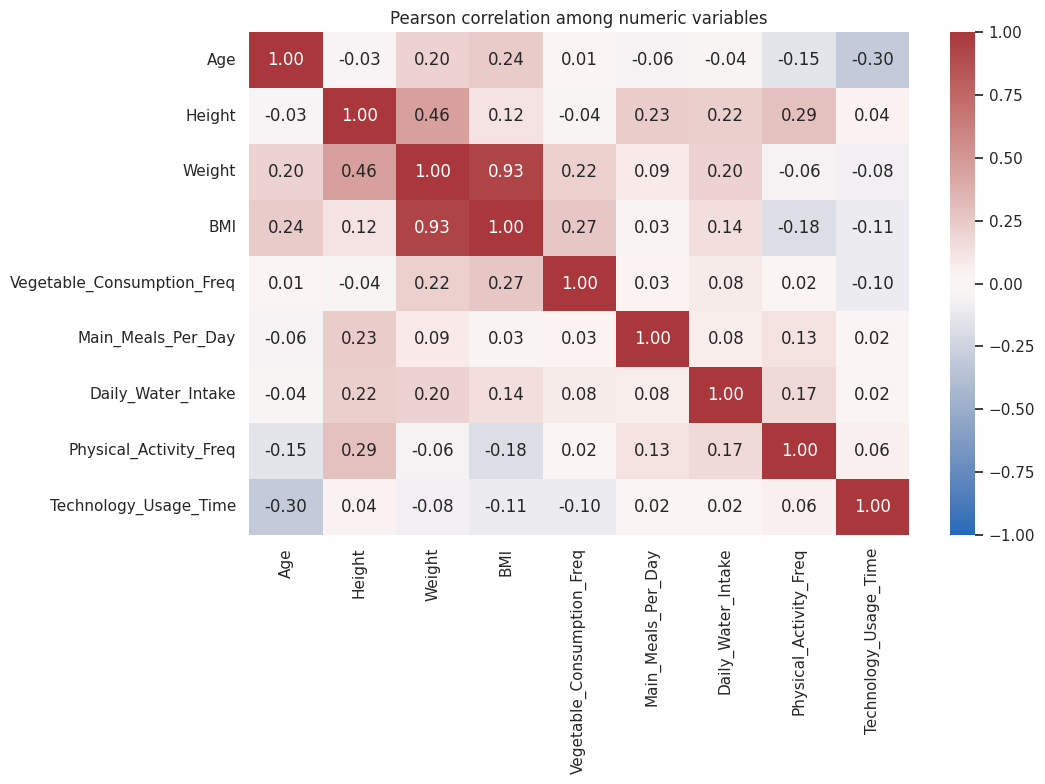

In [ ]:
correlation_columns = ["Age", "Height", "Weight", "BMI", "Vegetable_Consumption_Freq",
                       "Main_Meals_Per_Day", "Daily_Water_Intake", "Physical_Activity_Freq",
                       "Technology_Usage_Time"]
correlation_matrix = obesity_eda[correlation_columns].corr()
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Pearson correlation among numeric variables")
finish_plot(fig, "eda_06_correlation_heatmap.png")


### 5.7 Pearson versus Spearman: what do they tell us?
**Question:** Which numeric variables generally rise or fall as the
ordered obesity label becomes more severe? Pearson measures a straight
line relationship. Spearman first replaces values with ranks and asks
whether the relationship is generally increasing or decreasing, even when
the curve is not straight. Values near +1 move upward together, values near
−1 move in opposite directions, and values near 0 show little ordered
relationship. A large Pearson–Spearman difference suggests a non-linear or
outlier-sensitive pattern. The severity rank is analysis-only and is not fed
into the classifiers.

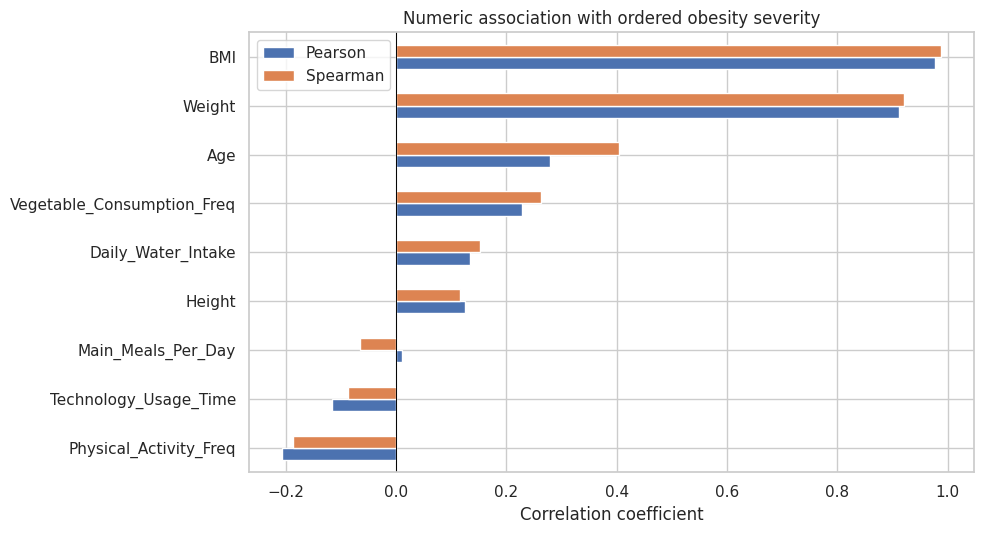

,Pearson,Spearman
Physical_Activity_Freq,-0.21,-0.19
Technology_Usage_Time,-0.12,-0.09
Main_Meals_Per_Day,0.01,-0.07
Height,0.12,0.12
Daily_Water_Intake,0.13,0.15
Vegetable_Consumption_Freq,0.23,0.26
Age,0.28,0.40
Weight,0.91,0.92
BMI,0.98,0.99


**Observation.** Use the two bars for the same variable together: similar heights suggest a roughly linear trend, while a visible gap suggests a curved or outlier-sensitive trend. Neither coefficient proves that the variable causes obesity.

In [ ]:
severity_columns = ["Age", "Height", "Weight", "BMI", "Vegetable_Consumption_Freq",
                    "Main_Meals_Per_Day", "Daily_Water_Intake", "Physical_Activity_Freq",
                    "Technology_Usage_Time"]
severity_association = pd.DataFrame({
    "Pearson": obesity_eda[severity_columns + ["Severity_Rank"]].corr(method="pearson")["Severity_Rank"].drop("Severity_Rank"),
    "Spearman": obesity_eda[severity_columns + ["Severity_Rank"]].corr(method="spearman")["Severity_Rank"].drop("Severity_Rank"),
}).sort_values("Spearman")
ax = severity_association.plot(kind="barh", figsize=(10, 5.5), color=["#4C72B0", "#DD8452"])
ax.set_title("Numeric association with ordered obesity severity")
ax.set_xlabel("Correlation coefficient")
ax.axvline(0, color="black", linewidth=0.7)
finish_plot(ax.figure, "eda_07_severity_association.png")
display(severity_association.round(3))
note("Use the two bars for the same variable together: similar heights suggest a roughly linear trend, while a visible gap suggests a curved or outlier-sensitive trend. Neither coefficient proves that the variable causes obesity.")

### 5.8 Lifestyle profile heatmap

**Question:** How do typical lifestyle scores differ by class? Cells show
the raw class median. Colour is display-normalised to each survey scale so
that variables measured on 0–2, 0–3 and 1–4 scales can be compared visually.
The raw medians remain printed below the chart.


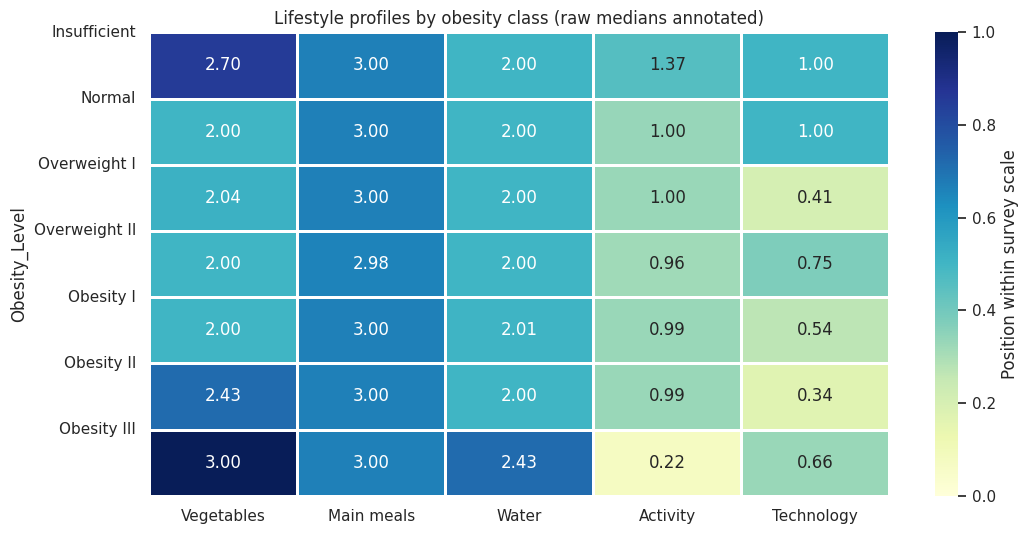

,Vegetables,Main meals,Water,Activity,Technology
Obesity_Level,,,,,
Insufficient,2.70,3.00,2.00,1.37,1.00
Normal,2.00,3.00,2.00,1.00,1.00
Overweight I,2.04,3.00,2.00,1.00,0.41
Overweight II,2.00,2.98,2.00,0.96,0.75
Obesity I,2.00,3.00,2.01,0.99,0.54
Obesity II,2.43,3.00,2.00,0.99,0.34
Obesity III,3.00,3.00,2.43,0.22,0.66


In [ ]:
lifestyle_columns = ["Vegetable_Consumption_Freq", "Main_Meals_Per_Day", "Daily_Water_Intake",
                     "Physical_Activity_Freq", "Technology_Usage_Time"]
lifestyle_labels = {
    "Vegetable_Consumption_Freq": "Vegetables",
    "Main_Meals_Per_Day": "Main meals",
    "Daily_Water_Intake": "Water",
    "Physical_Activity_Freq": "Activity",
    "Technology_Usage_Time": "Technology",
}
lifestyle_ranges = {"Vegetable_Consumption_Freq": (1, 3), "Main_Meals_Per_Day": (1, 4),
                    "Daily_Water_Intake": (1, 3), "Physical_Activity_Freq": (0, 3),
                    "Technology_Usage_Time": (0, 2)}
lifestyle_medians = obesity_eda.groupby("Obesity_Level", observed=True)[lifestyle_columns].median().reindex(obesity_order)
lifestyle_display = lifestyle_medians.copy()
for column, (low, high) in lifestyle_ranges.items():
    lifestyle_display[column] = (lifestyle_display[column] - low) / (high - low)
lifestyle_display.columns = [lifestyle_labels[c] for c in lifestyle_columns]
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(lifestyle_display, annot=lifestyle_medians.rename(columns=lifestyle_labels).round(2), fmt=".2f",
            cmap="YlGnBu", vmin=0, vmax=1, linewidths=0.8, cbar_kws={"label": "Position within survey scale"}, ax=ax)
ax.set_title("Lifestyle profiles by obesity class (raw medians annotated)")
ax.set_yticks(range(len(obesity_order)), [short_labels[x] for x in obesity_order], rotation=0)
finish_plot(fig, "eda_08_lifestyle_profiles.png")
display(lifestyle_medians.rename(index=short_labels, columns=lifestyle_labels).round(2))


### 5.9 Categorical association using bias-corrected Cramér’s V

**Question:** Which categorical survey fields have the strongest association
with the seven-class target? Cramér’s V measures association magnitude from
0 to 1 without pretending the category names have numeric distances. Smallest
group size is shown as a coverage warning; V is not feature importance.


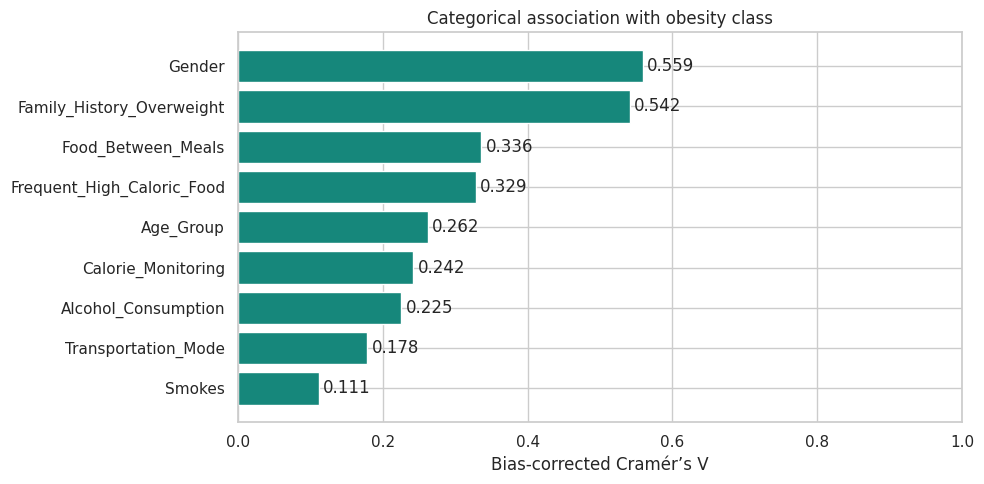

,Feature,Cramer's V,Smallest group,Categories
4,Smokes,0.11,44,2
7,Transportation_Mode,0.18,7,5
6,Alcohol_Consumption,0.23,1,4
5,Calorie_Monitoring,0.24,96,2
8,Age_Group,0.26,10,4
2,Frequent_High_Caloric_Food,0.33,243,2
3,Food_Between_Meals,0.34,37,4
1,Family_History_Overweight,0.54,365,2
0,Gender,0.56,1035,2


**Observation.** The ranking identifies fields worth exploring further, but it does not show direction and does not adjust for other variables. Group composition charts below provide that context.

In [ ]:
def cramers_v(table):
    observed = table.to_numpy(dtype=float)
    n = observed.sum()
    if n <= 1 or observed.shape[0] < 2 or observed.shape[1] < 2:
        return np.nan
    expected = np.outer(observed.sum(axis=1), observed.sum(axis=0)) / n
    chi2 = ((observed - expected) ** 2 / np.where(expected == 0, 1, expected)).sum()
    phi2 = max(0, chi2 / n - ((observed.shape[0] - 1) * (observed.shape[1] - 1)) / (n - 1))
    rows = observed.shape[0] - ((observed.shape[0] - 1) ** 2) / (n - 1)
    cols = observed.shape[1] - ((observed.shape[1] - 1) ** 2) / (n - 1)
    return np.sqrt(phi2 / min(rows - 1, cols - 1))

categorical_eda = ["Gender", "Family_History_Overweight", "Frequent_High_Caloric_Food",
                   "Food_Between_Meals", "Smokes", "Calorie_Monitoring",
                   "Alcohol_Consumption", "Transportation_Mode", "Age_Group"]
association_rows = []
for column in categorical_eda:
    table = pd.crosstab(obesity_eda[column], obesity_eda["Obesity_Level"]).reindex(columns=obesity_order, fill_value=0)
    association_rows.append({"Feature": column, "Cramer's V": cramers_v(table), "Smallest group": int(table.sum(axis=1).min()), "Categories": int(table.shape[0])})
association_table = pd.DataFrame(association_rows).sort_values("Cramer's V")
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(association_table["Feature"], association_table["Cramer's V"], color="#16877B")
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xlim(0, 1)
ax.set_xlabel("Bias-corrected Cramér’s V")
ax.set_title("Categorical association with obesity class")
finish_plot(fig, "eda_09_categorical_association.png")
display(association_table.round(3))
note("The ranking identifies fields worth exploring further, but it does not show direction and does not adjust for other variables. Group composition charts below provide that context.")


### 5.10 Within-category composition of the target

**Question:** How does the class mix change inside common categorical
groups? Each bar sums to 100% within that category, which prevents large
groups from looking important merely because they contain more records.


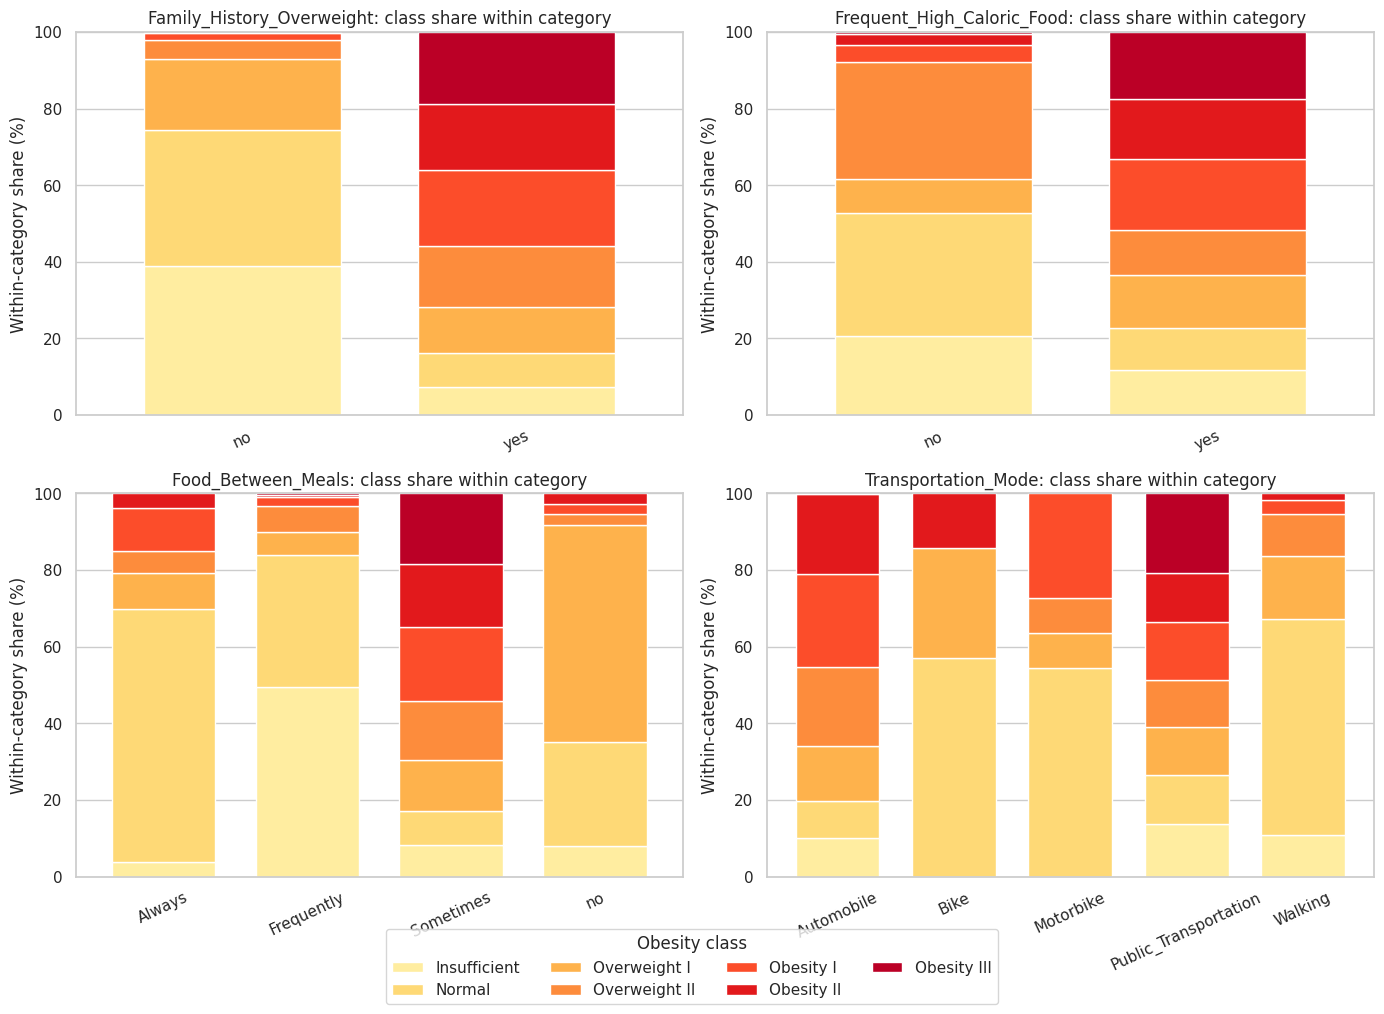

In [ ]:
composition_columns = ["Family_History_Overweight", "Frequent_High_Caloric_Food",
                       "Food_Between_Meals", "Transportation_Mode"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, column in zip(axes.flat, composition_columns):
    counts = pd.crosstab(obesity_eda[column], obesity_eda["Obesity_Level"]).reindex(columns=obesity_order, fill_value=0)
    percentages = counts.div(counts.sum(axis=1), axis=0).mul(100)
    percentages.rename(columns=short_labels).plot(kind="bar", stacked=True, color=obesity_palette, ax=ax, width=0.72, legend=False)
    ax.set_title(f"{column}: class share within category")
    ax.set_xlabel("")
    ax.set_ylabel("Within-category share (%)")
    ax.tick_params(axis="x", rotation=25)
    ax.set_ylim(0, 100)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Obesity class", loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02))
fig.subplots_adjust(bottom=0.20)
finish_plot(fig, "eda_10_categorical_composition.png")

### 5.11 Water intake by activity level

**Question:** Does average daily water intake differ across activity bands?
This uses a clearly labelled mean bar with a 95% confidence interval, not a
boxplot. The respondent count above each bar shows whether a comparison is
based on a large or small group.

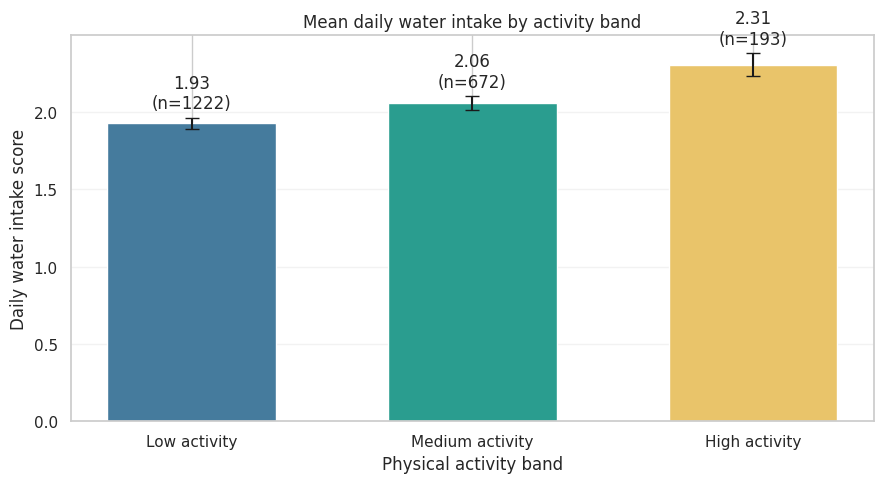

,Records,Mean,SD,95% CI
Activity_Band,,,,
Low activity,1222,1.93,0.61,0.03
Medium activity,672,2.06,0.59,0.04
High activity,193,2.31,0.53,0.07


**Observation.** The bars compare group means, while the capped lines show approximate 95% confidence intervals. This is a descriptive pattern and not evidence that activity causes a change in water intake.

In [ ]:
activity_band = pd.cut(obesity_eda["Physical_Activity_Freq"], bins=[-0.01, 1, 2, 3.01], labels=["Low activity", "Medium activity", "High activity"])
water_activity = obesity_eda.assign(Activity_Band=activity_band).groupby("Activity_Band", observed=True)["Daily_Water_Intake"].agg(Records="size", Mean="mean", SD="std")
water_activity["95% CI"] = 1.96 * water_activity["SD"] / np.sqrt(water_activity["Records"])
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(water_activity.index.astype(str), water_activity["Mean"], yerr=water_activity["95% CI"], capsize=5, color=["#457B9D", "#2A9D8F", "#E9C46A"], width=0.6)
ax.bar_label(bars, labels=[f"{mean:.2f}\n(n={n})" for mean, n in zip(water_activity["Mean"], water_activity["Records"])], padding=4)
ax.set_title("Mean daily water intake by activity band")
ax.set_xlabel("Physical activity band")
ax.set_ylabel("Daily water intake score")
ax.tick_params(axis="x", labelrotation=0)
ax.grid(axis="y", alpha=0.25)
finish_plot(fig, "eda_12_water_by_activity.png")
display(water_activity.round(3))
note("The bars compare group means, while the capped lines show approximate 95% confidence intervals. This is a descriptive pattern and not evidence that activity causes a change in water intake.")


### 5.12 Activity and technology-use interaction
**Question:** Does the combination of activity and technology use show a
different average severity pattern than either variable alone? Grouped bars
make the comparison easier to read than another dense matrix. The count table
below keeps sparse cells visible before drawing conclusions.

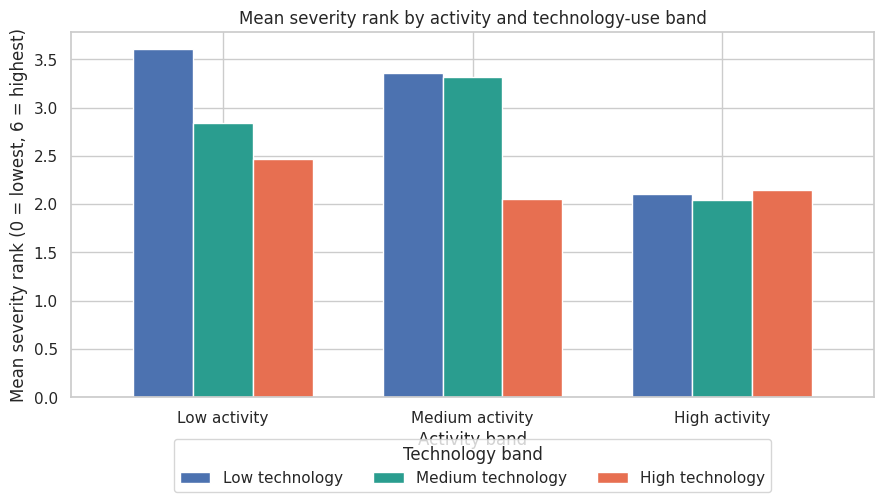

Technology band,Low technology,Medium technology,High technology
Activity band,,,
Low activity,3.60,2.84,2.46
Medium activity,3.36,3.32,2.06
High activity,2.10,2.04,2.14


Technology band,Low technology,Medium technology,High technology
Activity band,,,
Low activity,715,352,155
Medium activity,351,268,53
High activity,90,68,35


In [ ]:
activity_band = pd.cut(obesity_eda["Physical_Activity_Freq"], bins=[-0.01, 1, 2, 3.01], labels=["Low activity", "Medium activity", "High activity"])
technology_band = pd.cut(obesity_eda["Technology_Usage_Time"], bins=[-0.01, 0.75, 1.5, 2.01], labels=["Low technology", "Medium technology", "High technology"])
interaction = pd.DataFrame({"Activity band": activity_band, "Technology band": technology_band, "Severity": obesity_eda["Severity_Rank"]}).dropna()
means = interaction.pivot_table(index="Activity band", columns="Technology band", values="Severity", aggfunc="mean", observed=False)
counts = interaction.pivot_table(index="Activity band", columns="Technology band", values="Severity", aggfunc="size", observed=False)
fig, ax = plt.subplots(figsize=(9, 5))
means.plot(kind="bar", ax=ax, color=["#4C72B0", "#2A9D8F", "#E76F51"], width=0.72)
ax.set_title("Mean severity rank by activity and technology-use band")
ax.set_xlabel("Activity band")
ax.set_ylabel("Mean severity rank (0 = lowest, 6 = highest)")
ax.tick_params(axis="x", labelrotation=0)
ax.legend(title="Technology band", loc="lower center", bbox_to_anchor=(0.5, -0.28), ncol=3)
fig.subplots_adjust(bottom=0.28)
finish_plot(fig, "eda_12_activity_technology.png")
display(means.round(2))
display(counts.astype(int))



### 5.13 Age-group and class composition

**Question:** Are age bands represented differently across the target? The
row-normalised heatmap compares class percentages within each engineered
equal-width age group. The engineered age group is retained for EDA only.


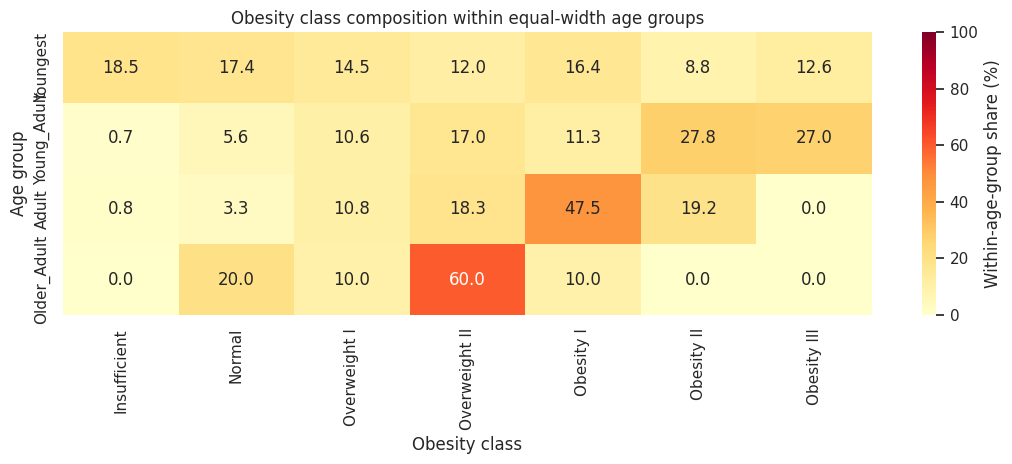

In [ ]:
age_class_counts = pd.crosstab(obesity_eda["Age_Group"], obesity_eda["Obesity_Level"]).reindex(columns=obesity_order, fill_value=0)
age_class_percentages = age_class_counts.div(age_class_counts.sum(axis=1), axis=0).mul(100)
fig, ax = plt.subplots(figsize=(11, 4.8))
sns.heatmap(age_class_percentages.rename(columns=short_labels), annot=True, fmt=".1f", cmap="YlOrRd", vmin=0, vmax=100, ax=ax, cbar_kws={"label": "Within-age-group share (%)"})
ax.set_title("Obesity class composition within equal-width age groups")
ax.set_xlabel("Obesity class")
ax.set_ylabel("Age group")
finish_plot(fig, "eda_13_age_group_composition.png")


### 5.14 Body measurements by gender
**Question:** How do the two continuous body measurements vary by gender?
These side-by-side boxplots are easier to interpret than the sparse daily
water boxplot and keep the focus on the observed sample distributions.

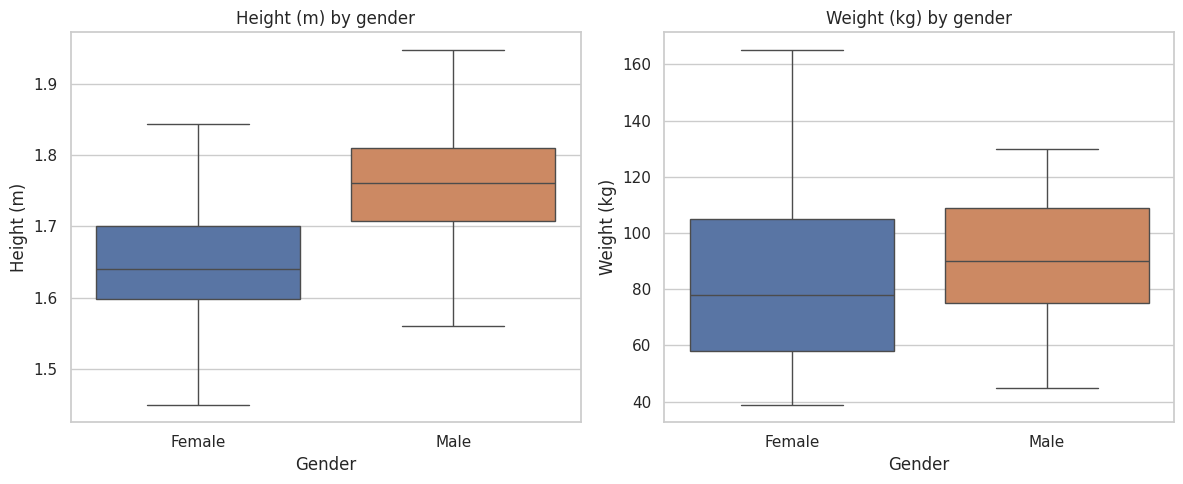

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, column, label in zip(axes, ["Height", "Weight"], ["Height (m)", "Weight (kg)"]):
    sns.boxplot(data=obesity_eda, x="Gender", y=column, hue="Gender", palette=["#4C72B0", "#DD8452"], legend=False, showfliers=False, ax=ax)
    ax.set_title(f"{label} by gender")
    ax.set_xlabel("Gender")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", labelrotation=0)
finish_plot(fig, "eda_14_body_measurements_gender.png")

### 5.15 BMI empirical cumulative distributions

**Question:** At any BMI threshold, how quickly do the class distributions
accumulate? ECDF curves avoid hiding sample size behind bins and make overlap
between neighbouring labels easy to see.


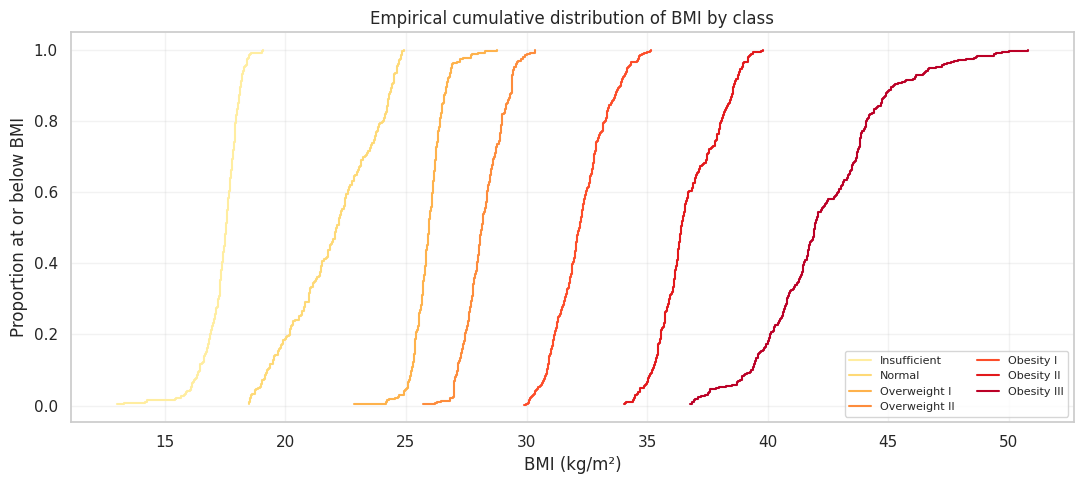

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
for label in obesity_order:
    values = np.sort(obesity_eda.loc[obesity_eda["Obesity_Level"] == label, "BMI"].dropna())
    y = np.arange(1, len(values) + 1) / len(values)
    ax.step(values, y, where="post", label=short_labels[label], color=obesity_colors[label])
ax.set_title("Empirical cumulative distribution of BMI by class")
ax.set_xlabel("BMI (kg/m²)")
ax.set_ylabel("Proportion at or below BMI")
ax.legend(ncol=2, fontsize=8)
ax.grid(alpha=0.25)
finish_plot(fig, "eda_15_bmi_ecdf.png")


### 5.16 OLAP-style drill-down

**Question:** How do multiple dimensions combine? The pivot tables roll up
BMI by gender and obesity class, then drill down to gender × transport ×
class counts. This is useful for discovering sparse groups that should be
treated cautiously in interpretation.


In [ ]:
olap_summary = pd.pivot_table(obesity_eda, index="Gender", columns="Obesity_Level", values="BMI", aggfunc="mean", margins=True, margins_name="All")
olap_summary = olap_summary.reindex(columns=obesity_order + ["All"]).rename(columns=short_labels)
print("Roll-up: mean BMI by gender and obesity class")
display(olap_summary.round(2))

olap_drilldown = pd.crosstab([obesity_eda["Gender"], obesity_eda["Transportation_Mode"]], obesity_eda["Obesity_Level"]).reindex(columns=obesity_order, fill_value=0)
print("Drill-down: counts by gender × transport × obesity class")
display(olap_drilldown.rename(columns=short_labels))

drilldown_long = olap_drilldown.reset_index().melt(id_vars=["Gender", "Transportation_Mode"], var_name="Obesity_Level", value_name="Records")
drilldown_fig = px.bar(drilldown_long, x="Transportation_Mode", y="Records", color="Obesity_Level", facet_row="Gender", category_orders={"Obesity_Level": obesity_order}, color_discrete_map=obesity_colors, title="Interactive OLAP drill-down: transport and gender")
drilldown_fig.update_layout(height=650)

print(
    "Interactive controls: hover over a bar for its count; "
    "click a legend class to hide/show it and double-click to isolate it; "
    "drag to zoom and use the toolbar to reset."
)
drilldown_fig.show()


Roll-up: mean BMI by gender and obesity class


Obesity_Level,Insufficient,Normal,Overweight I,Overweight II,Obesity I,Obesity II,Obesity III,All
Gender,,,,,,,,
Female,17.33,21.78,25.90,28.22,31.86,37.13,42.25,30.21
Male,17.50,22.22,26.02,28.21,32.57,36.72,49.47,29.33
All,17.39,22.01,25.96,28.22,32.26,36.72,42.27,29.77


Drill-down: counts by gender × transport × obesity class


Obesity_Level                 Insufficient  Normal  Overweight I  \
Gender Transportation_Mode                                         
Female Automobile                        1      25            44   
       Motorbike                         0       1             0   
       Public_Transportation           166      97            98   
       Walking                           2      14             3   
Male   Automobile                       45      19            22   
       Bike                              0       4             2   
       Motorbike                         0       5             1   
       Public_Transportation            49     100           100   
       Walking                           4      17             6   

Obesity_Level                 Overweight II  Obesity I  Obesity II  \
Gender Transportation_Mode                                           
Female Automobile                        40         55           0   
       Motorbike                          0          1           0   
       Public_Transportation             63         99           2   
       Walking                            0          1           0   
Male   Automobile                        54         55          95   
       Bike                               0          0           1   
       Motorbike                          1          2           0   
       Public_Transportation            126        137         198   
       Walking                            6          1           1   

Obesity_Level                 Obesity III  
Gender Transportation_Mode                 
Female Automobile                       1  
       Motorbike                        0  
       Public_Transportation          322  
       Walking                          0  
Male   Automobile                       0  
       Bike                             0  
       Motorbike                        0  
       Public_Transportation            1  
       Walking                          0

Interactive controls: hover over a bar for its count; click a legend class to hide/show it and double-click to isolate it; drag to zoom and use the toolbar to reset.


### 5.17 Interactive feature explorer

Choose any two numeric fields to redraw a Plotly scatter. The dropdowns,
legend, hover labels and zoom controls make this a compact way to test a
question before adding a static figure to a report. The default view uses
height and weight because it is easy to interpret alongside BMI.


In [ ]:
numeric_explorer_columns = [
    "Age",
    "Height",
    "Weight",
    "BMI",
    "Vegetable_Consumption_Freq",
    "Main_Meals_Per_Day",
    "Daily_Water_Intake",
    "Physical_Activity_Freq",
    "Technology_Usage_Time"
]

import ipywidgets as widgets
from IPython.display import display, clear_output

# Enable widget support in Google Colab
try:
    from google.colab import output
    output.enable_custom_widget_manager()
    plotly_renderer = "colab"
except ImportError:
    plotly_renderer = None

x_dropdown = widgets.Dropdown(
    options=numeric_explorer_columns,
    value="Height",
    description="X field:"
)

y_dropdown = widgets.Dropdown(
    options=numeric_explorer_columns,
    value="Weight",
    description="Y field:"
)

chart_output = widgets.Output()


def redraw_eda_scatter(change=None):
    with chart_output:
        clear_output(wait=True)

        x_column = x_dropdown.value
        y_column = y_dropdown.value

        if x_column == y_column:
            print("Please choose two different fields.")
            return

        figure = px.scatter(
            obesity_eda,
            x=x_column,
            y=y_column,
            color="Obesity_Level",
            symbol="Gender",
            category_orders={
                "Obesity_Level": obesity_order
            },
            color_discrete_map=obesity_colors,
            hover_data={
                "Age": ":.1f",
                "Height": ":.2f",
                "Weight": ":.1f",
                "BMI": ":.2f"
            },
            title=f"{x_column} versus {y_column}"
        )

        figure.update_layout(
            height=520,
            legend_title="Obesity class"
        )

        if plotly_renderer:
            figure.show(renderer=plotly_renderer)
        else:
            figure.show()


x_dropdown.observe(redraw_eda_scatter, names="value")
y_dropdown.observe(redraw_eda_scatter, names="value")

display(
    widgets.HBox([x_dropdown, y_dropdown]),
    chart_output
)

# Draw the initial chart
redraw_eda_scatter()

Output()

**EDA conclusion.** The charts establish class coverage, show strong body
measurement separation, quantify lifestyle and categorical associations,
and expose overlap and sparse groups. These findings guide interpretation
of the model results in Sections 7–9; they do not alter the original feature
list, scaling strategy or hyperparameter searches.


## 6. Machine Learning Preparation

In [ ]:
# ============================================================
# 6. MACHINE LEARNING PREPARATION
# ============================================================

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, multilabel_confusion_matrix, roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# BMI and Age_Group are EDA-only engineered columns (see Section 3.9-3.10)
# and are excluded here to avoid leakage / redundancy.
FEATURES_TO_EXCLUDE = ["Obesity_Level", "BMI", "Age_Group"]

X = obesity_cleaned.drop(columns=FEATURES_TO_EXCLUDE)
y = obesity_cleaned["Obesity_Level"]

label_encoder = LabelEncoder()
# Fit the encoder using the clinically-ordered class list so that the
# resulting integer codes (0..6) follow obesity severity order.
label_encoder.classes_ = np.array(obesity_order)
y_encoded = label_encoder.transform(y)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=RANDOM_STATE, stratify=y_encoded
)

one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# ============================================================
# MODEL-SPECIFIC PREPROCESSING OPTIONS
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)


# ------------------------------------------------------------
# One-hot encoder
# ------------------------------------------------------------

try:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )


# ------------------------------------------------------------
# A. TREE PREPROCESSOR
# Decision Tree + Random Forest
# No numerical scaling required
# ------------------------------------------------------------

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_features
        ),
        (
            "categorical",
            onehot,
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# B. STANDARD SCALER
# ------------------------------------------------------------

standard_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            onehot,
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# C. MIN-MAX SCALER
# ------------------------------------------------------------

minmax_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            MinMaxScaler(),
            numeric_features
        ),
        (
            "categorical",
            onehot,
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# D. ROBUST SCALER
# ------------------------------------------------------------

robust_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            RobustScaler(),
            numeric_features
        ),
        (
            "categorical",
            onehot,
            categorical_features
        )
    ]
)


# Current/default scaled preprocessing
scaled_preprocessor = standard_preprocessor


print("Tree preprocessor created.")
print("StandardScaler preprocessor created.")
print("MinMaxScaler preprocessor created.")
print("RobustScaler preprocessor created.")

# A single, consistent cross-validation strategy reused by every model
# below (baseline evaluation + hyperparameter tuning for models 2-4).
cv_strategy = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print("\nTraining observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])
print("Target classes (in severity order):", list(label_encoder.classes_))

Numeric features: ['Age', 'Height', 'Weight', 'Vegetable_Consumption_Freq', 'Main_Meals_Per_Day', 'Daily_Water_Intake', 'Physical_Activity_Freq', 'Technology_Usage_Time']
Categorical features: ['Gender', 'Family_History_Overweight', 'Frequent_High_Caloric_Food', 'Food_Between_Meals', 'Smokes', 'Calorie_Monitoring', 'Alcohol_Consumption', 'Transportation_Mode']
Tree preprocessor created.
StandardScaler preprocessor created.
MinMaxScaler preprocessor created.
RobustScaler preprocessor created.

Training observations: 1669
Testing observations: 418
Target classes (in severity order): [np.str_('Insufficient_Weight'), np.str_('Normal_Weight'), np.str_('Overweight_Level_I'), np.str_('Overweight_Level_II'), np.str_('Obesity_Type_I'), np.str_('Obesity_Type_II'), np.str_('Obesity_Type_III')]


In [ ]:
# ------------------------------------------------------------
# 6.1 Reusable model evaluation helper
# ------------------------------------------------------------

model_results = {}
fitted_pipelines = {}


def evaluate_model(
    name,
    pipeline,
    X_train,
    y_train,
    X_test,
    y_test,
    cv=cv_strategy
):

    # Fit model
    pipeline.fit(
        X_train,
        y_train
    )

    # Predictions
    y_train_pred = pipeline.predict(
        X_train
    )

    y_test_pred = pipeline.predict(
        X_test
    )


    # --------------------------------------------------------
    # Accuracy
    # --------------------------------------------------------

    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )

    test_accuracy = accuracy_score(
        y_test,
        y_test_pred
    )


    # --------------------------------------------------------
    # Macro Precision / Recall / F1
    # Equal importance to all 7 obesity classes
    # --------------------------------------------------------

    precision_macro = precision_score(
        y_test,
        y_test_pred,
        average="macro",
        zero_division=0
    )

    recall_macro = recall_score(
        y_test,
        y_test_pred,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_test,
        y_test_pred,
        average="macro",
        zero_division=0
    )


    # --------------------------------------------------------
    # Specificity
    # Multiclass = one-vs-rest for each class
    # Specificity = TN / (TN + FP)
    # --------------------------------------------------------

    mcm = multilabel_confusion_matrix(
        y_test,
        y_test_pred
    )

    specificity_values = []

    for cm in mcm:

        TN = cm[0, 0]
        FP = cm[0, 1]

        specificity = (
            TN / (TN + FP)
            if (TN + FP) > 0
            else 0
        )

        specificity_values.append(
            specificity
        )

    specificity_macro = np.mean(
        specificity_values
    )


    # --------------------------------------------------------
    # 5-fold CV Macro F1
    # --------------------------------------------------------

    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    cv_macro_f1 = cv_scores.mean()
    cv_std = cv_scores.std()


    # --------------------------------------------------------
    # Multiclass ROC-AUC
    # --------------------------------------------------------

    auc_macro = np.nan

    if hasattr(
        pipeline,
        "predict_proba"
    ):

        y_proba = pipeline.predict_proba(
            X_test
        )

        try:

            auc_macro = roc_auc_score(
                y_test,
                y_proba,
                multi_class="ovr",
                average="macro"
            )

        except ValueError:
            pass


    # --------------------------------------------------------
    # Train-test gap
    # --------------------------------------------------------

    overfit_gap = (
        train_accuracy -
        test_accuracy
    )


    # --------------------------------------------------------
    # Save metrics
    # --------------------------------------------------------

    results = {

        "Model":
            name,

        "CV_Macro_F1":
            cv_macro_f1,

        "CV_Std":
            cv_std,

        "Train_Accuracy":
            train_accuracy,

        "Test_Accuracy":
            test_accuracy,

        "Precision_Macro":
            precision_macro,

        "Recall_Macro":
            recall_macro,

        "F1_Macro":
            f1_macro,

        "Specificity_Macro":
            specificity_macro,

        "AUC_Macro_OVR":
            auc_macro,

        "Overfit_Gap":
            overfit_gap
    }


    model_results[name] = results

    fitted_pipelines[name] = pipeline


    # --------------------------------------------------------
    # Display
    # --------------------------------------------------------

    print("=" * 65)
    print(name)
    print("=" * 65)

    print(
        f"CV Macro F1       : "
        f"{cv_macro_f1:.4f} "
        f"(+/- {cv_std:.4f})"
    )

    print(
        f"Train Accuracy    : "
        f"{train_accuracy:.4f}"
    )

    print(
        f"Test Accuracy     : "
        f"{test_accuracy:.4f}"
    )

    print(
        f"Macro Precision   : "
        f"{precision_macro:.4f}"
    )

    print(
        f"Macro Recall      : "
        f"{recall_macro:.4f}"
    )

    print(
        f"Macro F1          : "
        f"{f1_macro:.4f}"
    )

    print(
        f"Macro Specificity : "
        f"{specificity_macro:.4f}"
    )

    print(
        f"Macro ROC-AUC     : "
        f"{auc_macro:.4f}"
    )

    print(
        f"Train-Test Gap    : "
        f"{overfit_gap:.4f}"
    )


    print(
        "\nClassification Report:\n"
    )

    print(
        classification_report(
            y_test,
            y_test_pred,
            target_names=
                label_encoder.classes_,
            zero_division=0
        )
    )


    return results, y_test_pred,

In [ ]:
# ------------------------------------------------------------
# Confusion Matrix Helper
# ------------------------------------------------------------

def plot_confusion_matrix(
    model_name,
    y_true,
    y_pred,
    ax=None
):
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        standalone_plot = True
    else:
        standalone_plot = False

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        ax=ax
    )

    ax.set_title(
        f"Confusion Matrix — {model_name}"
    )

    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

    ax.set_xticklabels(
        label_encoder.classes_,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(
        label_encoder.classes_,
        rotation=0
    )

    if standalone_plot:
        plt.tight_layout()
        plt.show()

## 7. Modelling

### 7a. Baseline Model — Decision Tree (Kyra)

In [ ]:
# ============================================================
# 7.1 MODEL 1 — DECISION TREE BASELINE
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score


# ------------------------------------------------------------
# Pipeline
# Tree-based models do not require numerical scaling
# ------------------------------------------------------------

dt_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)


# ------------------------------------------------------------
# Cross-validation on TRAINING data
# ------------------------------------------------------------

dt_cv_scores = cross_val_score(
    dt_pipeline,
    X_train,
    y_train,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1
)

dt_cv_macro_f1 = dt_cv_scores.mean()


print(
    "Decision Tree CV Macro F1 scores:"
)

print(
    dt_cv_scores
)

print(
    "Mean CV Macro F1:",
    round(
        dt_cv_macro_f1,
        4
    )
)


# ------------------------------------------------------------
# Final fitting on complete training set
# ------------------------------------------------------------

dt_pipeline.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# Evaluate using your existing common evaluation function
# ------------------------------------------------------------

baseline_results, y_pred_baseline = evaluate_model(
    "Decision Tree (Baseline)",
    dt_pipeline,
    X_train,
    y_train,
    X_test,
    y_test
)

Decision Tree CV Macro F1 scores:
[0.87419906 0.93638514 0.90158096 0.92603992 0.94152174]
Mean CV Macro F1: 0.9159
Decision Tree (Baseline)
CV Macro F1       : 0.9159 (+/- 0.0250)
Train Accuracy    : 1.0000
Test Accuracy     : 0.9330
Macro Precision   : 0.9319
Macro Recall      : 0.9296
Macro F1          : 0.9303
Macro Specificity : 0.9889
Macro ROC-AUC     : 0.9592
Train-Test Gap    : 0.0670

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.94      0.96      0.95        53
      Normal_Weight       0.85      0.82      0.84        57
 Overweight_Level_I       0.85      0.85      0.85        55
Overweight_Level_II       0.96      0.93      0.95        58
     Obesity_Type_I       0.92      1.00      0.96        70
    Obesity_Type_II       1.00      0.95      0.97        60
   Obesity_Type_III       0.98      0.98      0.98        65

           accuracy                           0.93       418
          macro avg       0

#### Baseline model evaluation

Baseline Model (Decision Tree) — Training vs Testing Performance
CV Macro F1        : 0.9159
Training Accuracy  : 1.0000
Testing Accuracy   : 0.9330
Overfitting Gap    : 0.0670
Macro Precision    : 0.9319
Macro Recall       : 0.9296
Macro F1-score     : 0.9303
Macro Specificity  : 0.9889
Macro ROC-AUC      : 0.9592


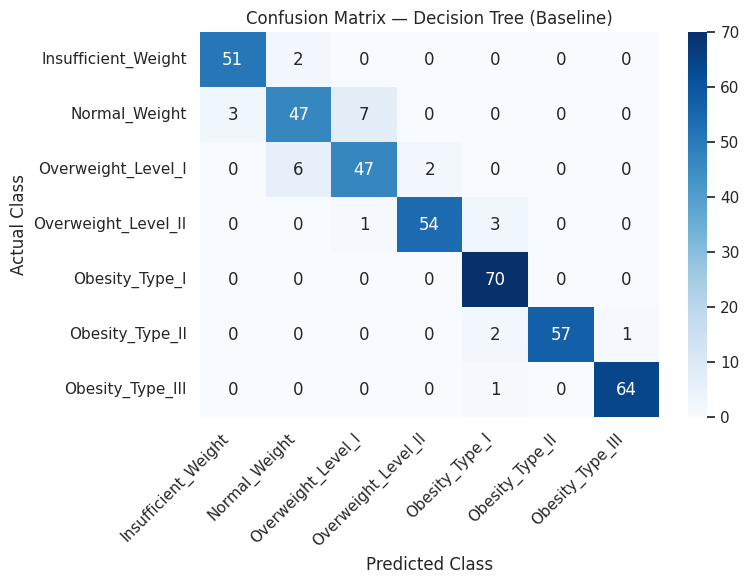

In [ ]:
# ============================================================
# EVALUATION — BASELINE MODEL (DECISION TREE)
# ============================================================
# Training and testing performance are both reported so that
# overfitting can be assessed consistently across models.

print("Baseline Model (Decision Tree) — Training vs Testing Performance")

print(
    f"CV Macro F1        : "
    f"{baseline_results['CV_Macro_F1']:.4f}"
)

print(
    f"Training Accuracy  : "
    f"{baseline_results['Train_Accuracy']:.4f}"
)

print(
    f"Testing Accuracy   : "
    f"{baseline_results['Test_Accuracy']:.4f}"
)

print(
    f"Overfitting Gap    : "
    f"{baseline_results['Overfit_Gap']:.4f}"
)

print(
    f"Macro Precision    : "
    f"{baseline_results['Precision_Macro']:.4f}"
)

print(
    f"Macro Recall       : "
    f"{baseline_results['Recall_Macro']:.4f}"
)

print(
    f"Macro F1-score     : "
    f"{baseline_results['F1_Macro']:.4f}"
)

print(
    f"Macro Specificity  : "
    f"{baseline_results['Specificity_Macro']:.4f}"
)

print(
    f"Macro ROC-AUC      : "
    f"{baseline_results['AUC_Macro_OVR']:.4f}"
)


plot_confusion_matrix(
    "Decision Tree (Baseline)",
    y_test,
    y_pred_baseline
)

**Short interpretation:** An untuned Decision Tree reaches a very high training accuracy
(often close to 100%) but a visibly lower test accuracy — the classic signature of **overfitting**
for unconstrained trees. This is expected and useful: it sets a baseline "floor" and an overfitting
benchmark that the tuned models in 7b-7d (which restrict tree depth / regularise / average many
trees) should improve upon.

### 7b. Model 2 — Random Forest (Liping)

In [ ]:
# ============================================================
# 7.2 MODEL 2 — RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline


# ------------------------------------------------------------
# Random Forest pipeline
# ------------------------------------------------------------

rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)


# ------------------------------------------------------------
# Advanced hyperparameter search space
# ------------------------------------------------------------

rf_param_grid = {

    # Number of trees
    "classifier__n_estimators": [
        100,
        200,
        300,
        500,
        700
    ],

    # Tree depth / complexity
    "classifier__max_depth": [
        5,
        8,
        10,
        15,
        20,
        None
    ],

    # Minimum records required to split
    "classifier__min_samples_split": [
        2,
        5,
        10,
        20
    ],

    # Minimum records per terminal leaf
    "classifier__min_samples_leaf": [
        1,
        2,
        5,
        10
    ],

    # Number of predictors considered per split
    "classifier__max_features": [
        "sqrt",
        "log2",
        0.5
    ],

    # Split-quality criterion
    "classifier__criterion": [
        "gini",
        "entropy"
    ],

    # Test whether class weighting helps
    "classifier__class_weight": [
        None,
        "balanced",
        "balanced_subsample"
    ]
}


# ------------------------------------------------------------
# Randomized Search
# ------------------------------------------------------------

rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=100,
    scoring="f1_macro",
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=1
)


# ------------------------------------------------------------
# Tune using TRAINING data only
# ------------------------------------------------------------

rf_random_search.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# Best configuration
# ------------------------------------------------------------

print(
    "\nBest Random Forest Parameters:"
)

print(
    rf_random_search.best_params_
)

print(
    "\nBest RF CV Macro F1:",
    round(
        rf_random_search.best_score_,
        4
    )
)


# ------------------------------------------------------------
# Retrieve final tuned RF
# ------------------------------------------------------------

rf_best_model = (
    rf_random_search.best_estimator_
)


# ------------------------------------------------------------
# Common evaluation
# ------------------------------------------------------------

rf_results, y_pred_rf = evaluate_model(
    "Random Forest",
    rf_best_model,
    X_train,
    y_train,
    X_test,
    y_test
)

Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best Random Forest Parameters:
{'classifier__n_estimators': 500, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 0.5, 'classifier__max_depth': 10, 'classifier__criterion': 'entropy', 'classifier__class_weight': 'balanced'}

Best RF CV Macro F1: 0.9455
Random Forest
CV Macro F1       : 0.9455 (+/- 0.0120)
Train Accuracy    : 0.9988
Test Accuracy     : 0.9641
Macro Precision   : 0.9645
Macro Recall      : 0.9623
Macro F1          : 0.9631
Macro Specificity : 0.9940
Macro ROC-AUC     : 0.9989
Train-Test Gap    : 0.0347

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        53
      Normal_Weight       0.90      0.95      0.92        57
 Overweight_Level_I       0.94      0.89      0.92        55
Overweight_Level_II       0.98      0.97      0.97        58
     Obesity_Type_I       0.96  

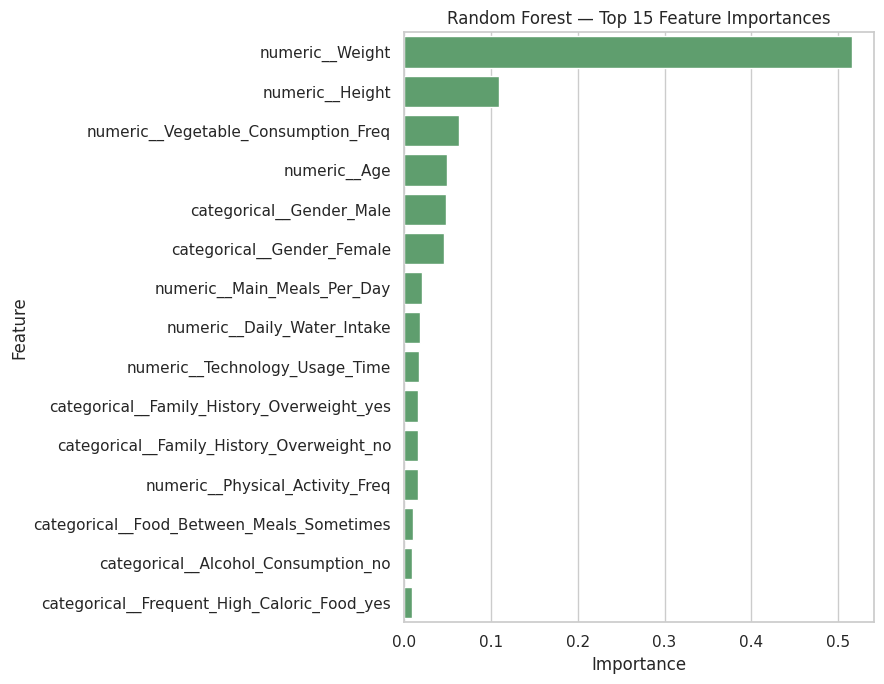

In [ ]:
# ------------------------------------------------------------
# Random Forest — Feature importance
# ------------------------------------------------------------

rf_feature_names = rf_best_model.named_steps["preprocessor"].get_feature_names_out()
rf_importances = rf_best_model.named_steps["classifier"].feature_importances_

rf_importance_df = pd.DataFrame({
    "Feature": rf_feature_names, "Importance": rf_importances
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(data=rf_importance_df, x="Importance", y="Feature", color="#55A868")
plt.title("Random Forest — Top 15 Feature Importances")
plt.tight_layout()
plt.show()

**Short interpretation:** Grid-searching `n_estimators`, `max_depth`, and
`min_samples_split` with 5-fold cross-validation lets the Random Forest regularise itself far
better than the untuned baseline tree — the train/test accuracy gap should shrink noticeably.
`Weight` and `Height` dominate the feature-importance ranking (consistent with the EDA scatterplot
in Section 5.8), followed by lifestyle features such as `Family_History_Overweight` and
`Physical_Activity_Freq`, which matter more for the business recommendation (lifestyle factors are
things people can actually change; Height/Weight are diagnostic, not actionable).

### 7c. Model 3 — Support Vector Machine (Wenhsuan)

In [ ]:
# ============================================================
# 7.3A SVM — PREPROCESSING / SCALER SELECTION
# ============================================================

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score


svm_scaler_options = {

    "StandardScaler":
        standard_preprocessor,

    "MinMaxScaler":
        minmax_preprocessor,

    "RobustScaler":
        robust_preprocessor
}


svm_scaler_results = []


for scaler_name, scaler_preprocessor in (
    svm_scaler_options.items()
):

    scaler_test_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                scaler_preprocessor
            ),
            (
                "classifier",
                SVC(
                    kernel="rbf",
                    C=1,
                    gamma="scale",
                    random_state=RANDOM_STATE
                )
            )
        ]
    )


    cv_scores = cross_val_score(
        scaler_test_pipeline,
        X_train,
        y_train,
        scoring="f1_macro",
        cv=cv_strategy,
        n_jobs=-1
    )


    svm_scaler_results.append({

        "Scaler":
            scaler_name,

        "CV_Macro_F1_Mean":
            cv_scores.mean(),

        "CV_Macro_F1_SD":
            cv_scores.std()
    })


svm_scaler_df = (
    pd.DataFrame(
        svm_scaler_results
    )
    .sort_values(
        "CV_Macro_F1_Mean",
        ascending=False
    )
)


print(
    "SVM Scaler Comparison:"
)

display(
    svm_scaler_df.round(4)
)


# ------------------------------------------------------------
# Select best scaler
# ------------------------------------------------------------

best_svm_scaler_name = (
    svm_scaler_df.iloc[0]["Scaler"]
)


best_svm_preprocessor = (
    svm_scaler_options[
        best_svm_scaler_name
    ]
)


print(
    "\nSelected SVM scaler:",
    best_svm_scaler_name
)

SVM Scaler Comparison:


,Scaler,CV_Macro_F1_Mean,CV_Macro_F1_SD
0,StandardScaler,0.90,0.01
2,RobustScaler,0.85,0.01
1,MinMaxScaler,0.73,0.03



Selected SVM scaler: StandardScaler


In [ ]:
# ============================================================
# 7.3B SVM — ADVANCED HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import GridSearchCV


svm_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            best_svm_preprocessor
        ),
        (
            "classifier",
            SVC(
                probability=True,
                random_state=RANDOM_STATE
            )
        )
    ]
)


# ------------------------------------------------------------
# Advanced parameter grid
# ------------------------------------------------------------

svm_param_grid = [

    # ========================================================
    # LINEAR SVM
    # ========================================================

    {
        "classifier__kernel": [
            "linear"
        ],

        # C controls regularisation
        "classifier__C": [
            0.001,
            0.01,
            0.1,
            1,
            10,
            100,
            1000
        ],

        "classifier__class_weight": [
            None,
            "balanced"
        ]
    },


    # ========================================================
    # RBF SVM
    # ========================================================

    {
        "classifier__kernel": [
            "rbf"
        ],

        "classifier__C": [
            0.01,
            0.1,
            1,
            10,
            100,
            1000
        ],

        # Controls how local the RBF influence is
        "classifier__gamma": [
            "scale",
            0.0001,
            0.001,
            0.01,
            0.1,
            1
        ],

        "classifier__class_weight": [
            None,
            "balanced"
        ]
    },


    # ========================================================
    # POLYNOMIAL SVM
    # ========================================================

    {
        "classifier__kernel": [
            "poly"
        ],

        "classifier__C": [
            0.1,
            1,
            10,
            100
        ],

        "classifier__degree": [
            2,
            3,
            4
        ],

        "classifier__gamma": [
            "scale",
            0.01,
            0.1
        ],

        "classifier__coef0": [
            0,
            0.1,
            1
        ],

        "classifier__class_weight": [
            None,
            "balanced"
        ]
    }
]


# ------------------------------------------------------------
# Grid Search
# ------------------------------------------------------------

svm_grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True,
    verbose=1
)


svm_grid_search.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print(
    "\nBest SVM Parameters:"
)

print(
    svm_grid_search.best_params_
)

print(
    "\nBest SVM CV Macro F1:",
    round(
        svm_grid_search.best_score_,
        4
    )
)


# ------------------------------------------------------------
# Best model
# ------------------------------------------------------------

svm_best_model = (
    svm_grid_search.best_estimator_
)


# ------------------------------------------------------------
# Common evaluation
# ------------------------------------------------------------

svm_results, y_pred_svm = evaluate_model(
    "SVM",
    svm_best_model,
    X_train,
    y_train,
    X_test,
    y_test
)

Fitting 5 folds for each of 302 candidates, totalling 1510 fits

Best SVM Parameters:
{'classifier__C': 100, 'classifier__class_weight': 'balanced', 'classifier__coef0': 1, 'classifier__degree': 2, 'classifier__gamma': 0.01, 'classifier__kernel': 'poly'}

Best SVM CV Macro F1: 0.9599
SVM
CV Macro F1       : 0.9599 (+/- 0.0098)
Train Accuracy    : 0.9958
Test Accuracy     : 0.9761
Macro Precision   : 0.9767
Macro Recall      : 0.9758
Macro F1          : 0.9760
Macro Specificity : 0.9960
Macro ROC-AUC     : 0.9981
Train-Test Gap    : 0.0197

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        53
      Normal_Weight       0.97      0.98      0.97        57
 Overweight_Level_I       0.96      0.96      0.96        55
Overweight_Level_II       1.00      0.95      0.97        58
     Obesity_Type_I       0.96      1.00      0.98        70
    Obesity_Type_II       0.98      0.97      0.97        60
  

**Short interpretation:** SVM tuning searches over the regularisation strength `C`, the
`kernel` (linear vs RBF) and `gamma`. Because SVM is distance-based, the `StandardScaler` applied
inside the shared `preprocessor` is essential here — without it, features on larger numeric scales
(e.g. `Weight`) would dominate the decision boundary. SVM typically performs competitively with
Random Forest on this dataset, though it can be more sensitive to the one-hot-encoded categorical
features inflating the dimensionality of the input space.

### 7d. Model 4 — K-Nearest Neighbours (Gladys)

In [ ]:
# ============================================================
# 7.4A KNN — PREPROCESSING / SCALER SELECTION
# ============================================================

from sklearn.neighbors import KNeighborsClassifier


knn_scaler_options = {

    "StandardScaler":
        standard_preprocessor,

    "MinMaxScaler":
        minmax_preprocessor,

    "RobustScaler":
        robust_preprocessor
}


knn_scaler_results = []


for scaler_name, scaler_preprocessor in (
    knn_scaler_options.items()
):

    scaler_test_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                scaler_preprocessor
            ),
            (
                "classifier",
                KNeighborsClassifier(
                    n_neighbors=5
                )
            )
        ]
    )


    cv_scores = cross_val_score(
        scaler_test_pipeline,
        X_train,
        y_train,
        scoring="f1_macro",
        cv=cv_strategy,
        n_jobs=-1
    )


    knn_scaler_results.append({

        "Scaler":
            scaler_name,

        "CV_Macro_F1_Mean":
            cv_scores.mean(),

        "CV_Macro_F1_SD":
            cv_scores.std()
    })


knn_scaler_df = (
    pd.DataFrame(
        knn_scaler_results
    )
    .sort_values(
        "CV_Macro_F1_Mean",
        ascending=False
    )
)


print(
    "KNN Scaler Comparison:"
)

display(
    knn_scaler_df.round(4)
)


# ------------------------------------------------------------
# Best scaler
# ------------------------------------------------------------

best_knn_scaler_name = (
    knn_scaler_df.iloc[0]["Scaler"]
)


best_knn_preprocessor = (
    knn_scaler_options[
        best_knn_scaler_name
    ]
)


print(
    "\nSelected KNN scaler:",
    best_knn_scaler_name
)

KNN Scaler Comparison:


,Scaler,CV_Macro_F1_Mean,CV_Macro_F1_SD
0,StandardScaler,0.80,0.02
2,RobustScaler,0.78,0.02
1,MinMaxScaler,0.75,0.03



Selected KNN scaler: StandardScaler


In [ ]:
# ============================================================
# 7.4B KNN — ADVANCED HYPERPARAMETER TUNING
# ============================================================


knn_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            best_knn_preprocessor
        ),
        (
            "classifier",
            KNeighborsClassifier()
        )
    ]
)


knn_param_grid = {

    # --------------------------------------------------------
    # Number of neighbours
    # --------------------------------------------------------

    "classifier__n_neighbors": [
        3,
        5,
        7,
        9,
        11,
        13,
        15,
        17,
        19,
        21,
        25,
        29,
        35
    ],

    # --------------------------------------------------------
    # Voting strategy
    # --------------------------------------------------------

    "classifier__weights": [
        "uniform",
        "distance"
    ],

    # --------------------------------------------------------
    # p=1 -> Manhattan distance
    # p=2 -> Euclidean distance
    # --------------------------------------------------------

    "classifier__p": [
        1,
        2
    ],

    # --------------------------------------------------------
    # Search-tree computational configuration
    # --------------------------------------------------------

    "classifier__leaf_size": [
        10,
        20,
        30,
        40,
        50
    ]
}


knn_grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True,
    verbose=1
)


knn_grid_search.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# Best configuration
# ------------------------------------------------------------

print(
    "\nBest KNN Parameters:"
)

print(
    knn_grid_search.best_params_
)

print(
    "\nBest KNN CV Macro F1:",
    round(
        knn_grid_search.best_score_,
        4
    )
)


# ------------------------------------------------------------
# Best model
# ------------------------------------------------------------

knn_best_model = (
    knn_grid_search.best_estimator_
)


# ------------------------------------------------------------
# Common evaluation
# ------------------------------------------------------------

knn_results, y_pred_knn = evaluate_model(
    "KNN",
    knn_best_model,
    X_train,
    y_train,
    X_test,
    y_test
)

Fitting 5 folds for each of 260 candidates, totalling 1300 fits

Best KNN Parameters:
{'classifier__leaf_size': 10, 'classifier__n_neighbors': 5, 'classifier__p': 1, 'classifier__weights': 'distance'}

Best KNN CV Macro F1: 0.868
KNN
CV Macro F1       : 0.8680 (+/- 0.0203)
Train Accuracy    : 1.0000
Test Accuracy     : 0.8660
Macro Precision   : 0.8581
Macro Recall      : 0.8599
Macro F1          : 0.8562
Macro Specificity : 0.9777
Macro ROC-AUC     : 0.9717
Train-Test Gap    : 0.1340

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.83      0.92      0.88        53
      Normal_Weight       0.74      0.54      0.63        57
 Overweight_Level_I       0.83      0.82      0.83        55
Overweight_Level_II       0.77      0.81      0.79        58
     Obesity_Type_I       0.88      0.97      0.93        70
    Obesity_Type_II       0.97      0.97      0.97        60
   Obesity_Type_III       0.98      0.98      0.98       

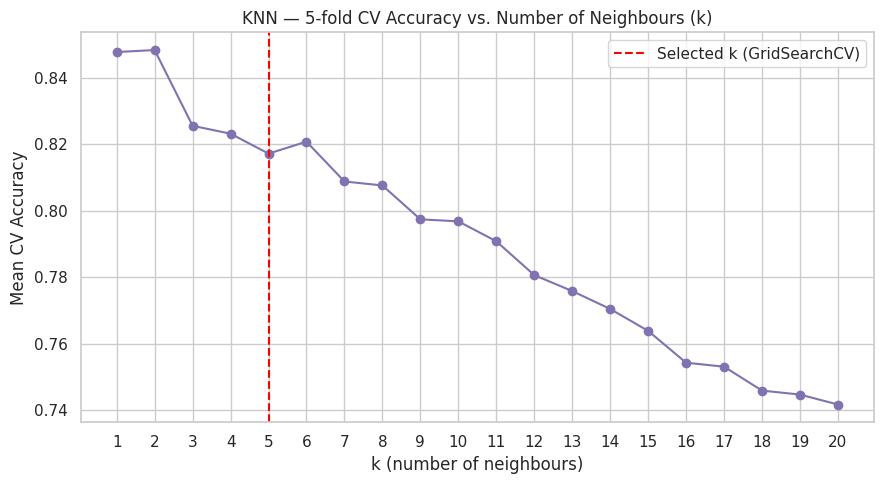

In [ ]:
# ------------------------------------------------------------
# KNN — sensitivity of accuracy to the choice of k
# ------------------------------------------------------------

k_values = list(range(1, 21))
k_cv_scores = []

for k in k_values:
    knn_k_pipeline = Pipeline(steps=[
        ("preprocessor", best_knn_preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(knn_k_pipeline, X_train, y_train, cv=cv_strategy, scoring="accuracy", n_jobs=-1)
    k_cv_scores.append(scores.mean())

plt.figure(figsize=(9, 5))
plt.plot(k_values, k_cv_scores, marker="o", color="#8172B2")
plt.axvline(
    knn_grid_search.best_params_["classifier__n_neighbors"],
    color="red", linestyle="--", label="Selected k (GridSearchCV)"
)
plt.title(f"KNN — {N_FOLDS}-fold CV Accuracy vs. Number of Neighbours (k)")
plt.xlabel("k (number of neighbours)")
plt.ylabel("Mean CV Accuracy")
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

**Short interpretation:** The k-sensitivity curve typically shows accuracy rising sharply
from `k=1` (which overfits to individual noisy neighbours) before flattening out and slowly
declining as `k` grows very large (which underfits by over-smoothing class boundaries). The `k`
chosen by `GridSearchCV` should sit near the peak of this curve, giving confidence that the
hyperparameter search converged on a sensible value rather than a spurious one.

In [ ]:
# ============================================================
# PREPROCESSING AND OPTIMISATION SUMMARY
# ============================================================

preprocessing_summary = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Random Forest",
        "SVM",
        "KNN"
    ],

    "Numerical Preprocessing": [
        "None / Passthrough",
        "None / Passthrough",
        best_svm_scaler_name,
        best_knn_scaler_name
    ],

    "Categorical Preprocessing": [
        "OneHotEncoder",
        "OneHotEncoder",
        "OneHotEncoder",
        "OneHotEncoder"
    ],

    "Tuning Method": [
        "None — Baseline",
        "RandomizedSearchCV",
        "GridSearchCV",
        "GridSearchCV"
    ],

    "CV Selection Metric": [
        "Macro F1",
        "Macro F1",
        "Macro F1",
        "Macro F1"
    ],

    "Main Complexity Control": [
        "Untuned baseline",
        "Depth / leaves / splits",
        "C / gamma / kernel",
        "Number of neighbours"
    ]
})


display(
    preprocessing_summary
)

,Model,Numerical Preprocessing,Categorical Preprocessing,Tuning Method,CV Selection Metric,Main Complexity Control
0,Decision Tree,None / Passthrough,OneHotEncoder,None — Baseline,Macro F1,Untuned baseline
1,Random Forest,None / Passthrough,OneHotEncoder,RandomizedSearchCV,Macro F1,Depth / leaves / splits
2,SVM,StandardScaler,OneHotEncoder,GridSearchCV,Macro F1,C / gamma / kernel
3,KNN,StandardScaler,OneHotEncoder,GridSearchCV,Macro F1,Number of neighbours


## 8. Model Evaluation and Comparison

In [ ]:
from IPython.display import display
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, multilabel_confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc,
)

required_variables = [
    "fitted_pipelines", "X_train", "X_test", "y_train", "y_test", "label_encoder",
]
missing_variables = [name for name in required_variables if name not in globals()]
if missing_variables:
    raise RuntimeError("Run Sections 6 and 7 first. Missing: " + ", ".join(missing_variables))
if not fitted_pipelines:
    raise ValueError("fitted_pipelines is empty. Fit the four models in Section 7 first.")

class_codes = np.arange(len(label_encoder.classes_))
class_names = label_encoder.inverse_transform(class_codes)
train_labels = np.asarray(y_train)
test_labels = np.asarray(y_test)
if not np.array_equal(np.unique(train_labels), class_codes):
    raise ValueError("y_train must use this label_encoder and contain every target class.")
if not np.isin(test_labels, class_codes).all():
    raise ValueError("y_test contains labels outside the fitted label encoder.")

# Reuse the notebook's existing CV splitter when available.
section8_cv = globals().get("cv_strategy")
if section8_cv is None:
    section8_cv = StratifiedKFold(n_splits=5, shuffle=True,
                                 random_state=globals().get("RANDOM_STATE", 42))
section8_splits = list(section8_cv.split(X_train, train_labels))
section8_fold_count = len(section8_splits)
for train_positions, validation_positions in section8_splits:
    if not np.array_equal(np.unique(train_labels[train_positions]), class_codes):
        raise ValueError("Each training fold must contain all classes; check class counts and CV.")
validation_counts = np.zeros(len(train_labels), dtype=int)
for _, positions in section8_splits:
    validation_counts[positions] += 1
if not np.all(validation_counts == 1):
    raise ValueError("Use ordinary stratified K-fold CV: each row must be validated exactly once.")

def section8_take_rows(frame, positions):
    return frame.iloc[positions] if hasattr(frame, "iloc") else frame[positions]

def section8_probabilities(estimator, features):
    """Align probability columns to label_encoder, not clinical severity order."""
    if not hasattr(estimator, "predict_proba"):
        return None
    probabilities = np.asarray(estimator.predict_proba(features), dtype=float)
    estimator_classes = np.asarray(estimator.classes_)
    if len(estimator_classes) != len(class_codes) or set(estimator_classes) != set(class_codes):
        raise ValueError("Model classes do not match the label encoder.")
    positions = [int(np.flatnonzero(estimator_classes == code)[0]) for code in class_codes]
    aligned = probabilities[:, positions]
    if not np.isfinite(aligned).all() or not np.allclose(aligned.sum(axis=1), 1):
        raise ValueError("Invalid class probabilities returned by the model.")
    return aligned

preferred_order = ["Decision Tree (Baseline)", "Random Forest", "SVM", "KNN"]
model_order = [name for name in preferred_order if name in fitted_pipelines]
model_order += [name for name in fitted_pipelines if name not in model_order]
metric_rows = []
predictions_by_model = {}
probabilities_by_model = {}
oof_probabilities_by_model = {}
cv_scores_by_model = {}
specificity_by_model = {}

for name in model_order:
    pipeline = fitted_pipelines[name]
    print(f"Evaluating {name}: {section8_fold_count} training-data CV folds...", flush=True)
    train_prediction = pipeline.predict(X_train)
    test_prediction = pipeline.predict(X_test)
    predictions_by_model[name] = test_prediction
    test_probability = section8_probabilities(pipeline, X_test)
    probabilities_by_model[name] = test_probability

    # One set of fits calculates both CV accuracy and CV Macro F1.
    cv_result = cross_validate(
        clone(pipeline), X_train, train_labels, cv=section8_splits,
        scoring={"accuracy": "accuracy", "macro_f1": "f1_macro"},
        return_estimator=True, n_jobs=1, error_score="raise",
    )
    cv_scores_by_model[name] = pd.DataFrame({
        "Fold": np.arange(1, section8_fold_count + 1),
        "Accuracy": cv_result["test_accuracy"],
        "Macro_F1": cv_result["test_macro_f1"],
    })

    # Reuse these validation predictions later to select a screening threshold.
    if test_probability is not None:
        oof_probability = np.full((len(train_labels), len(class_codes)), np.nan)
        for (_, positions), fold_model in zip(section8_splits, cv_result["estimator"]):
            oof_probability[positions] = section8_probabilities(
                fold_model, section8_take_rows(X_train, positions)
            )
        if not np.isfinite(oof_probability).all():
            raise ValueError("Some training rows have no out-of-fold probability.")
        oof_probabilities_by_model[name] = oof_probability

    # Each class is positive in turn; all other classes are negative.
    class_matrices = multilabel_confusion_matrix(test_labels, test_prediction, labels=class_codes)
    tn = class_matrices[:, 0, 0].astype(float)
    fp = class_matrices[:, 0, 1].astype(float)
    specificity = np.divide(tn, tn + fp, out=np.full_like(tn, np.nan), where=(tn + fp) != 0)
    specificity_by_model[name] = specificity

    row = {
        "Model": name,
        "Train_Accuracy": accuracy_score(train_labels, train_prediction),
        "Test_Accuracy": accuracy_score(test_labels, test_prediction),
        "CV_Macro_F1": cv_result["test_macro_f1"].mean(),
        "CV_Std_Macro_F1": cv_result["test_macro_f1"].std(),
        "CV_Mean_Accuracy": cv_result["test_accuracy"].mean(),
        "CV_Std_Accuracy": cv_result["test_accuracy"].std(),
        "Specificity_Macro": float(np.nanmean(specificity)),
        "AUC_Macro_OVR": np.nan,
        "AUC_Weighted_OVR": np.nan,
    }
    for average, suffix in [("macro", "Macro"), ("weighted", "Weighted")]:
        for metric_name, metric in [("Precision", precision_score), ("Recall", recall_score), ("F1", f1_score)]:
            row[f"{metric_name}_{suffix}"] = metric(
                test_labels, test_prediction, labels=class_codes,
                average=average, zero_division=0,
            )
    # Multiclass AUC requires every class in the test set and probability scores.
    if test_probability is not None and np.array_equal(np.unique(test_labels), class_codes):
        row["AUC_Macro_OVR"] = roc_auc_score(
            test_labels, test_probability, labels=class_codes, multi_class="ovr", average="macro")
        row["AUC_Weighted_OVR"] = roc_auc_score(
            test_labels, test_probability, labels=class_codes, multi_class="ovr", average="weighted")
    else:
        print(f"{name}: AUC is unavailable (no probabilities or a missing test class).")
    row["Error_Rate"] = 1 - row["Test_Accuracy"]
    row["Overfit_Gap"] = row["Train_Accuracy"] - row["Test_Accuracy"]
    row["Generalisation_Ratio"] = (row["Test_Accuracy"] / row["Train_Accuracy"]
                                   if row["Train_Accuracy"] else np.nan)
    metric_rows.append(row)
    del cv_result  # CV copies are no longer needed; original fitted models remain unchanged.

results_df = pd.DataFrame(metric_rows).set_index("Model").loc[model_order]
print("Ready: macro, weighted, specificity, AUC and CV metrics have been calculated.")

Evaluating Decision Tree (Baseline): 5 training-data CV folds...
Evaluating Random Forest: 5 training-data CV folds...
Evaluating SVM: 5 training-data CV folds...
Evaluating KNN: 5 training-data CV folds...
Ready: macro, weighted, specificity, AUC and CV metrics have been calculated.


### 8.1 Consolidated model comparison
All six previously missing columns now exist before they are selected. Macro specificity is the average of TN/(TN+FP), treating each class as positive in turn. It may be high because each class has many negatives; it is not accuracy. Similar metric values are valid and are reported without forcing differences.

In [ ]:
consolidated_columns = [
    "CV_Macro_F1", "Train_Accuracy", "Test_Accuracy", "Error_Rate",
    "Precision_Macro", "Recall_Macro", "F1_Macro", "Specificity_Macro",
    "AUC_Macro_OVR", "Overfit_Gap", "Generalisation_Ratio",
]
consolidated_comparison = results_df[consolidated_columns].sort_values(
    "CV_Macro_F1", ascending=False, kind="stable")
results_df_display = consolidated_comparison.round(4)
display(results_df_display.style.format("{:.4f}"))


,CV_Macro_F1,Train_Accuracy,Test_Accuracy,Error_Rate,Precision_Macro,Recall_Macro,F1_Macro,Specificity_Macro,AUC_Macro_OVR,Overfit_Gap,Generalisation_Ratio
Model,,,,,,,,,,,
SVM,0.9599,0.9958,0.9761,0.0239,0.9767,0.9758,0.9760,0.9960,0.9981,0.0197,0.9802
Random Forest,0.9455,0.9988,0.9641,0.0359,0.9645,0.9623,0.9631,0.9940,0.9989,0.0347,0.9653
Decision Tree (Baseline),0.9159,1.0000,0.9330,0.0670,0.9319,0.9296,0.9303,0.9889,0.9592,0.0670,0.9330
KNN,0.8680,1.0000,0.8660,0.1340,0.8581,0.8599,0.8562,0.9777,0.9717,0.1340,0.8660


### 8.2(a) Inner comparison: training, cross-validation and test
Compare accuracy with accuracy in the chart. CV Macro F1 is reported separately in the table; a difference between two different metrics is not an overfitting gap. In-sample training accuracy can legitimately be 1.0 for flexible models.

,Train_Accuracy,CV_Mean_Accuracy,Test_Accuracy,CV_Macro_F1
Model,,,,
Decision Tree (Baseline),1.00,0.92,0.93,0.92
Random Forest,1.00,0.95,0.96,0.95
SVM,1.00,0.96,0.98,0.96
KNN,1.00,0.88,0.87,0.87


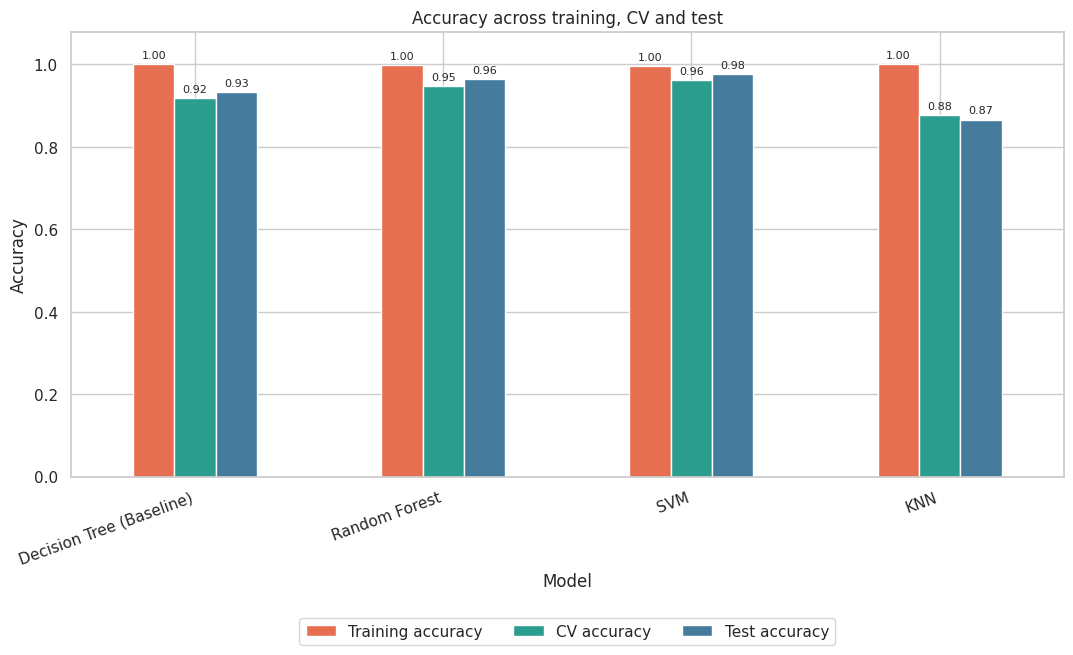

In [ ]:
inner_comparison = results_df[["Train_Accuracy", "CV_Mean_Accuracy", "Test_Accuracy"]]
display(results_df[["Train_Accuracy", "CV_Mean_Accuracy", "Test_Accuracy", "CV_Macro_F1"]].round(4))
ax = inner_comparison.rename(columns={
    "Train_Accuracy": "Training accuracy", "CV_Mean_Accuracy": "CV accuracy",
    "Test_Accuracy": "Test accuracy",
}).plot.bar(figsize=(11, 7), color=["#E76F51", "#2A9D8F", "#457B9D"])
for container in ax.containers: ax.bar_label(container,fmt="%.2f",padding=3,fontsize=8)
ax.set(title="Accuracy across training, CV and test", ylabel="Accuracy", ylim=(0, 1.08))
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=3
)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


### 8.2(b) Generalisation gap
This is training accuracy minus test accuracy. Read it with absolute scores and cross-validation performance; a small gap alone does not establish quality.

,Overfit_Gap
Model,
KNN,0.13
Decision Tree (Baseline),0.07
Random Forest,0.03
SVM,0.02


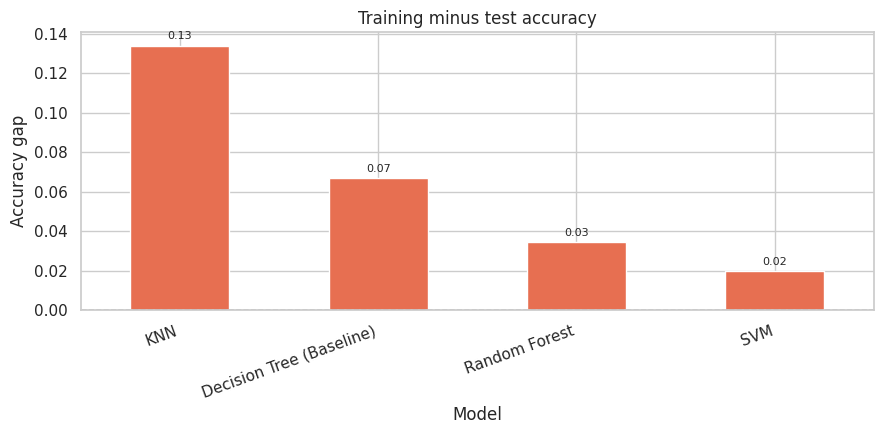

In [ ]:
overfit_comparison = results_df[["Overfit_Gap"]].sort_values("Overfit_Gap", ascending=False)
display(overfit_comparison.round(4))
ax = overfit_comparison.plot.bar(figsize=(9, 4.5), color="#E76F51", legend=False)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
for container in ax.containers: ax.bar_label(container,fmt="%.2f",padding=3,fontsize=8)
ax.set(title="Training minus test accuracy", ylabel="Accuracy gap")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


### 8.3 Outer comparison: the four test metrics
Accuracy counts all correct predictions. Macro precision, recall and F1 each average the corresponding class-level scores equally. Use exact table values when the bars are close; this is not a calculation error.

,Test_Accuracy,Precision_Macro,Recall_Macro,F1_Macro
Model,,,,
Decision Tree (Baseline),0.93,0.93,0.93,0.93
Random Forest,0.96,0.96,0.96,0.96
SVM,0.98,0.98,0.98,0.98
KNN,0.87,0.86,0.86,0.86


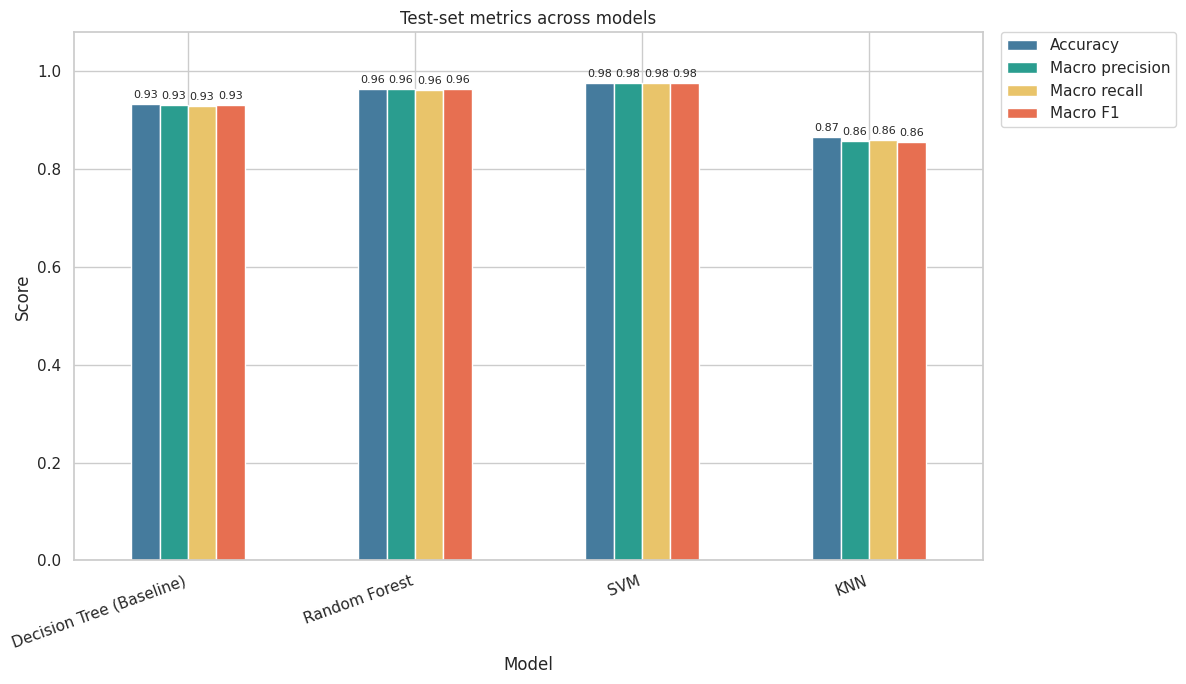

In [ ]:
outer_comparison = results_df[["Test_Accuracy", "Precision_Macro", "Recall_Macro", "F1_Macro"]]
display(outer_comparison.round(4))
ax = outer_comparison.rename(columns={
    "Test_Accuracy": "Accuracy", "Precision_Macro": "Macro precision",
    "Recall_Macro": "Macro recall", "F1_Macro": "Macro F1",
}).plot.bar(figsize=(12, 7), color=["#457B9D", "#2A9D8F", "#E9C46A", "#E76F51"])
for container in ax.containers: ax.bar_label(container,fmt="%.2f",padding=3,fontsize=8)
ax.set(title="Test-set metrics across models", ylabel="Score", ylim=(0, 1.08))
plt.xticks(rotation=20, ha="right")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()


### 8.4 Confusion matrices: all models
Rows are actual classes; columns are predictions. The label encoder's order is
used explicitly for both axes so the names always match the matrix entries.

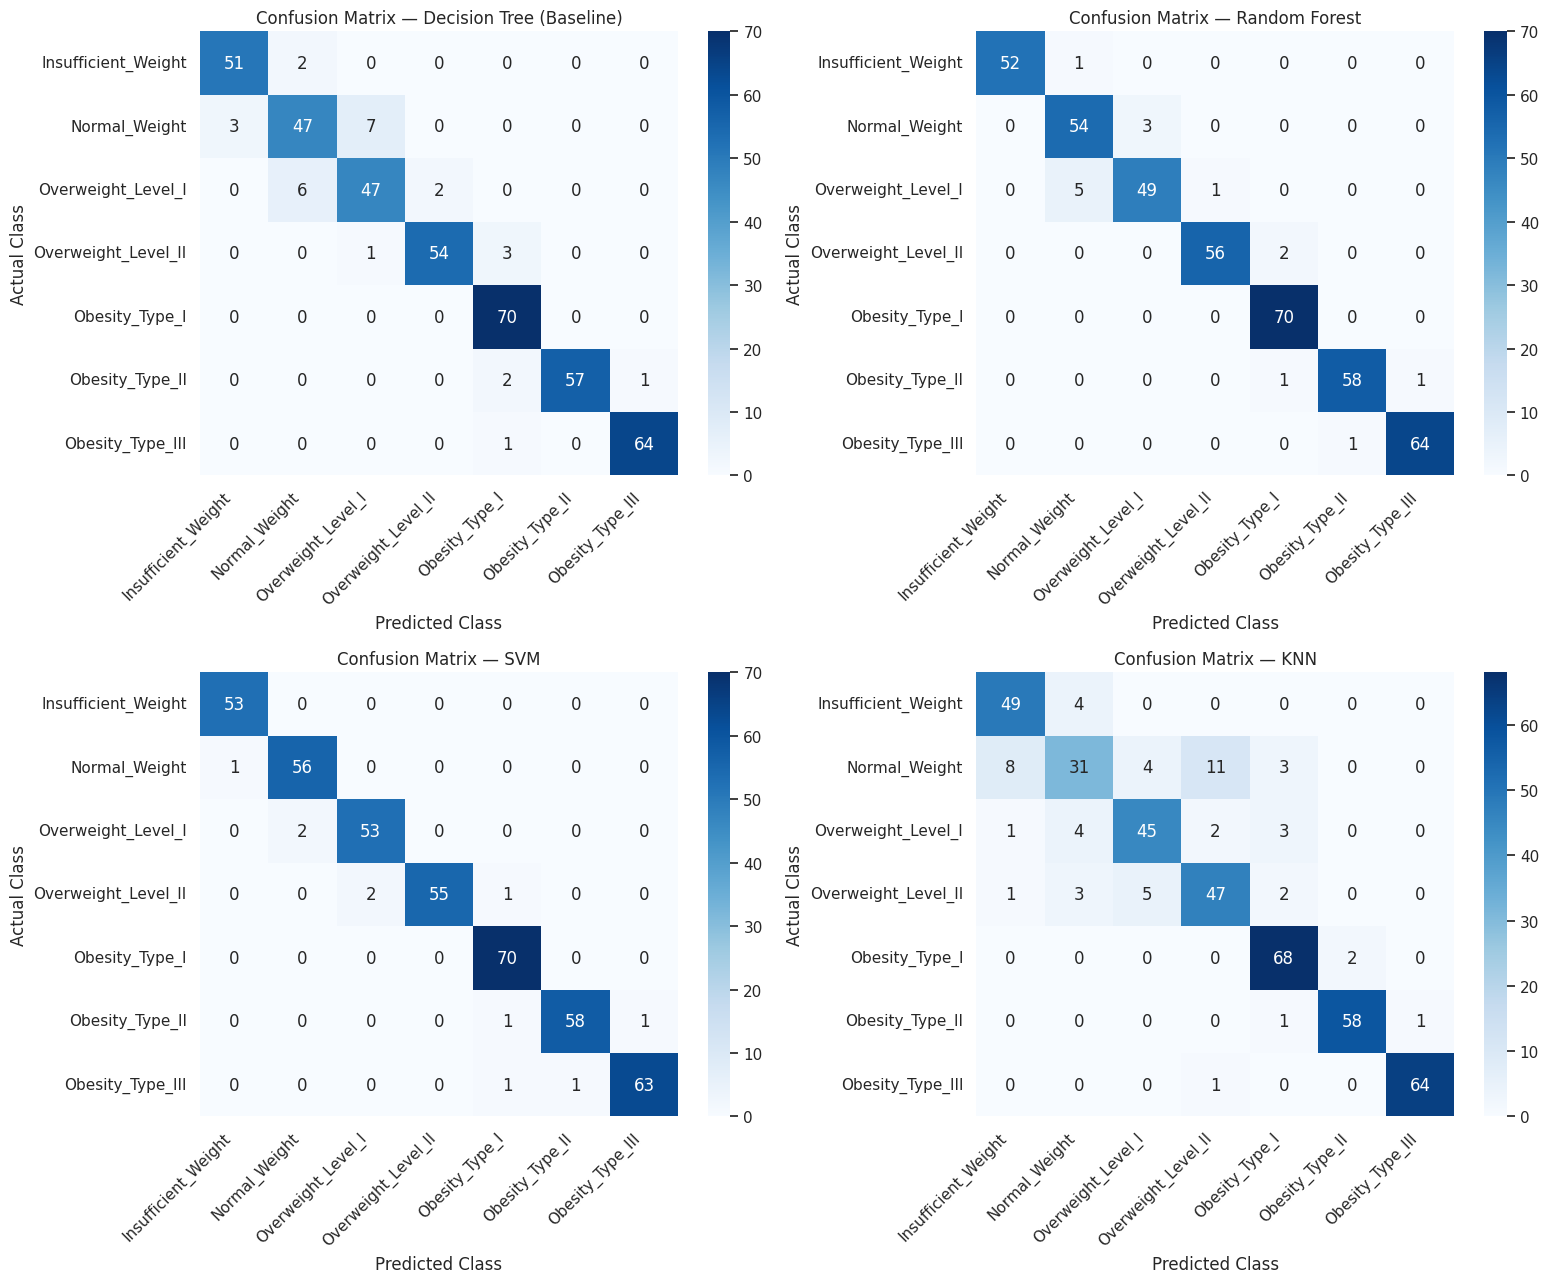

In [ ]:
# ============================================================
# 8.4 Confusion matrices for all four models
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.flatten()

predictions_by_model = {
    "Decision Tree (Baseline)": y_pred_baseline,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "KNN": y_pred_knn,
}

for ax, (name, y_pred) in zip(axes, predictions_by_model.items()):
    plot_confusion_matrix(name, y_test, y_pred, ax=ax)

plt.tight_layout()
plt.show()

### 8.5 Macro one-vs-rest AUC comparison
AUC describes score ranking across thresholds, not the fraction classified
correctly. Models are still selected by training CV Macro F1, not by test AUC.

,AUC_Macro_OVR
Model,
Decision Tree (Baseline),0.96
Random Forest,1.00
SVM,1.00
KNN,0.97


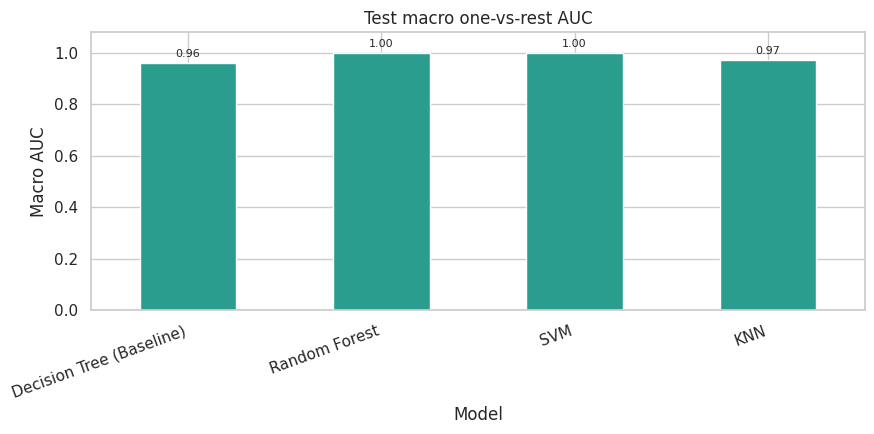

In [ ]:
display(results_df[["AUC_Macro_OVR"]].round(4))
available_auc = results_df["AUC_Macro_OVR"].dropna()
if not available_auc.empty:
    ax = available_auc.plot.bar(figsize=(9, 4.5), color="#2A9D8F")
    for container in ax.containers: ax.bar_label(container,fmt="%.2f",padding=3,fontsize=8)
    ax.set(title="Test macro one-vs-rest AUC", ylabel="Macro AUC", ylim=(0, 1.08))
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


### 8.6 ROC curves for the CV-leading candidate
The candidate is identified using training CV Macro F1 before drawing its ROC
curves. The following selection cell confirms the same choice. Test scores are
displayed for evaluation only. A tie uses the existing model order.

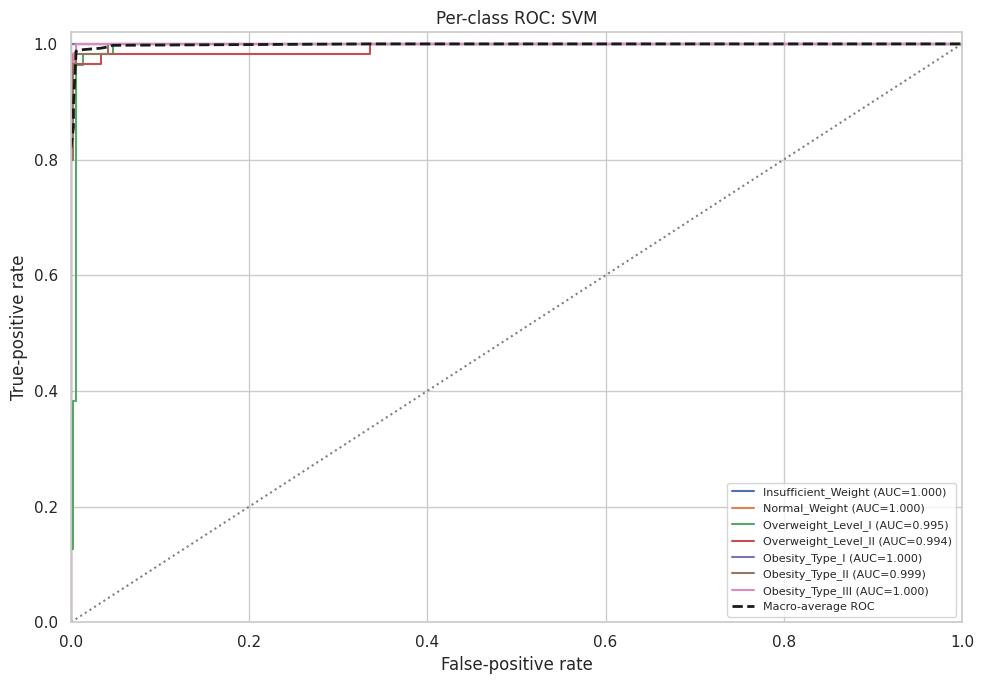

In [ ]:
selection_ranking = results_df.sort_values("CV_Macro_F1", ascending=False, kind="stable")
cv_leading_name = selection_ranking.index[0]
candidate_probabilities = probabilities_by_model[cv_leading_name]
if candidate_probabilities is None:
    print(f"ROC curves unavailable: {cv_leading_name} does not provide probabilities.")
else:
    fig, ax = plt.subplots(figsize=(10, 7))
    fpr_all, tpr_all = [], []
    for column, (class_code, class_name) in enumerate(zip(class_codes, class_names)):
        binary_target = (test_labels == class_code).astype(int)
        if len(np.unique(binary_target)) < 2:
            print(f"Skipping {class_name}: test data must contain positives and negatives.")
            continue
        fpr, tpr, _ = roc_curve(binary_target, candidate_probabilities[:, column])
        fpr_all.append(fpr)
        tpr_all.append(tpr)
        ax.plot(fpr, tpr, label=f"{class_name} (AUC={auc(fpr, tpr):.3f})")
    if fpr_all:
        all_fpr = np.unique(np.concatenate(fpr_all))
        mean_tpr = np.mean([np.interp(all_fpr, fpr, tpr) for fpr, tpr in zip(fpr_all, tpr_all)], axis=0)
        ax.plot(all_fpr, mean_tpr, "k--", linewidth=2, label="Macro-average ROC")
    ax.plot([0, 1], [0, 1], color="grey", linestyle=":")
    ax.set(title=f"Per-class ROC: {cv_leading_name}", xlabel="False-positive rate",
           ylabel="True-positive rate", xlim=(0, 1), ylim=(0, 1.02))
    ax.legend(fontsize=8, loc="lower right")
    fig.tight_layout()
    plt.show()


### 8.7 Final model selection
Highest training CV Macro F1 is the single selection criterion. Test metrics
are supporting evaluation results and are not tie-breakers.

In [ ]:
best_model_name = selection_ranking.index[0]
best_pipeline = fitted_pipelines[best_model_name]
print("Selected final model:", best_model_name)
print(f"Selection criterion: highest {section8_fold_count}-fold CV Macro F1")
print(f"CV Macro F1: {results_df.loc[best_model_name, 'CV_Macro_F1']:.4f}")
print(f"Final test accuracy: {results_df.loc[best_model_name, 'Test_Accuracy']:.4f}")
print(f"Final test Macro F1: {results_df.loc[best_model_name, 'F1_Macro']:.4f}")
display(selection_ranking[["CV_Macro_F1", "CV_Std_Macro_F1", "Test_Accuracy",
                           "Precision_Macro", "Recall_Macro", "F1_Macro"]].style.format("{:.4f}"))


Selected final model: SVM
Selection criterion: highest 5-fold CV Macro F1
CV Macro F1: 0.9599
Final test accuracy: 0.9761
Final test Macro F1: 0.9760


,CV_Macro_F1,CV_Std_Macro_F1,Test_Accuracy,Precision_Macro,Recall_Macro,F1_Macro
Model,,,,,,
SVM,0.9599,0.0098,0.9761,0.9767,0.9758,0.9760
Random Forest,0.9455,0.0120,0.9641,0.9645,0.9623,0.9631
Decision Tree (Baseline),0.9159,0.0250,0.9330,0.9319,0.9296,0.9303
KNN,0.8680,0.0203,0.8660,0.8581,0.8599,0.8562


### 8.8 Per-class results for the selected model
This shows which labels are difficult even when the overall scores are high.

In [ ]:
selected_class_report = pd.DataFrame(classification_report(
    test_labels, predictions_by_model[best_model_name], labels=class_codes,
    target_names=class_names, zero_division=0, output_dict=True,
)).T.loc[class_names].copy()
selected_class_report["specificity"] = specificity_by_model[best_model_name]
display(selected_class_report.round(4))


,precision,recall,f1-score,support,specificity
Insufficient_Weight,0.98,1.00,0.99,53.00,1.00
Normal_Weight,0.97,0.98,0.97,57.00,0.99
Overweight_Level_I,0.96,0.96,0.96,55.00,0.99
Overweight_Level_II,1.00,0.95,0.97,58.00,1.00
Obesity_Type_I,0.96,1.00,0.98,70.00,0.99
Obesity_Type_II,0.98,0.97,0.97,60.00,1.00
Obesity_Type_III,0.98,0.97,0.98,65.00,1.00


### 8.9 Cost-sensitive obesity-label threshold analysis
This is an educational binary task: Obesity Types I–III versus the other labels.
It does not predict future clinical risk. FN cost=5 and FP cost=1 are illustrative
assumptions, not clinically validated costs. Probabilities are not guaranteed to
be calibrated. Select the threshold with out-of-fold training probabilities,
then evaluate the locked threshold on the test set. Never select it from test
labels. CV scores after choosing configurations can still be optimistic; this
is not a nested validation of the entire selection process.

Threshold selection uses training out-of-fold predictions only.
Illustrative costs: FN=5, FP=1


,Threshold,TP,FP,FN,TN,Sensitivity,Specificity,Total_Cost,Mean_Cost
0,0.10,777,25,0,867,1.00,0.97,25.00,0.01
1,0.15,776,20,1,872,1.00,0.98,25.00,0.01
2,0.20,776,15,1,877,1.00,0.98,20.00,0.01
3,0.25,773,10,4,882,0.99,0.99,30.00,0.02
4,0.30,772,9,5,883,0.99,0.99,34.00,0.02
5,0.35,772,6,5,886,0.99,0.99,31.00,0.02
6,0.40,772,5,5,887,0.99,0.99,30.00,0.02
7,0.45,770,5,7,887,0.99,0.99,40.00,0.02
8,0.50,770,5,7,887,0.99,0.99,40.00,0.02
9,0.55,770,4,7,888,0.99,1.00,39.00,0.02


Selected threshold in the specified 0.10–0.90 grid: 0.20


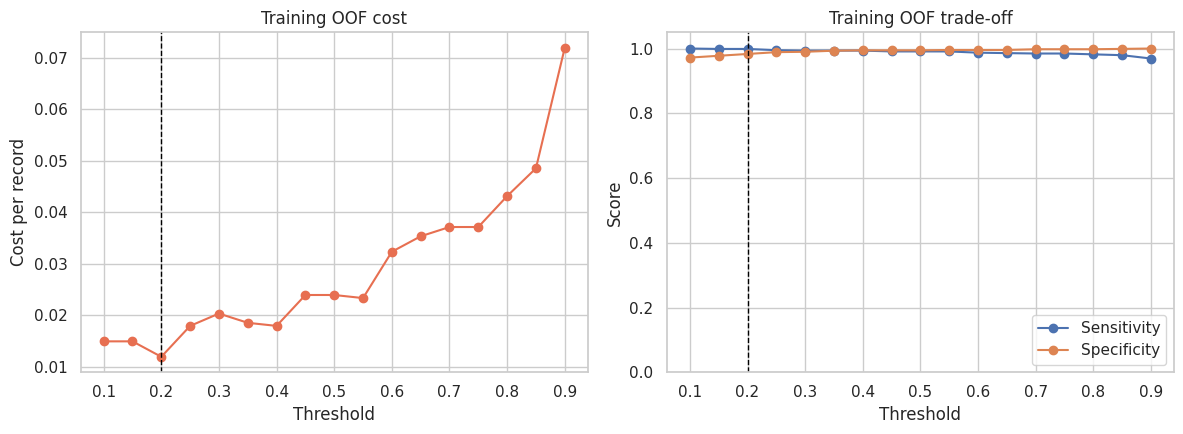

Test evaluation at the locked threshold:


,Threshold,TP,FP,FN,TN,Sensitivity,Specificity,Total_Cost,Mean_Cost
0,0.20,195,1,0,222,1.00,1.00,1.00,0.00


In [ ]:
HIGH_RISK_LEVELS = ["Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"]
FALSE_NEGATIVE_COST = 5
FALSE_POSITIVE_COST = 1
high_risk_codes = label_encoder.transform(HIGH_RISK_LEVELS)
high_risk_columns = [int(np.flatnonzero(class_codes == code)[0]) for code in high_risk_codes]

def section8_threshold_row(actual, probability, threshold):
    predicted = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[0, 1]).ravel()
    total_cost = FALSE_NEGATIVE_COST * fn + FALSE_POSITIVE_COST * fp
    return {
        "Threshold": float(threshold), "TP": int(tp), "FP": int(fp),
        "FN": int(fn), "TN": int(tn),
        "Sensitivity": tp / (tp + fn) if tp + fn else np.nan,
        "Specificity": tn / (tn + fp) if tn + fp else np.nan,
        "Total_Cost": float(total_cost), "Mean_Cost": float(total_cost / len(actual)),
    }

if best_model_name not in oof_probabilities_by_model:
    print("Threshold analysis skipped: selected model does not provide probabilities.")
else:
    training_high_risk = np.isin(train_labels, high_risk_codes).astype(int)
    oof_high_risk_probability = oof_probabilities_by_model[best_model_name][:, high_risk_columns].sum(axis=1)
    threshold_results = pd.DataFrame([
        section8_threshold_row(training_high_risk, oof_high_risk_probability, threshold)
        for threshold in np.round(np.arange(0.10, 0.91, 0.05), 2)
    ])
    selected_threshold_row = threshold_results.sort_values(
        ["Total_Cost", "FN", "Threshold"], kind="stable").iloc[0]
    selected_threshold = float(selected_threshold_row["Threshold"])
    print("Threshold selection uses training out-of-fold predictions only.")
    print(f"Illustrative costs: FN={FALSE_NEGATIVE_COST}, FP={FALSE_POSITIVE_COST}")
    display(threshold_results.round(4))
    print(f"Selected threshold in the specified 0.10–0.90 grid: {selected_threshold:.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].plot(threshold_results["Threshold"], threshold_results["Mean_Cost"], marker="o", color="#E76F51")
    axes[0].set(title="Training OOF cost", xlabel="Threshold", ylabel="Cost per record")
    for metric in ["Sensitivity", "Specificity"]:
        axes[1].plot(threshold_results["Threshold"], threshold_results[metric], marker="o", label=metric)
    axes[1].set(title="Training OOF trade-off", xlabel="Threshold", ylabel="Score", ylim=(0, 1.05))
    axes[1].legend()
    for ax in axes:
        ax.axvline(selected_threshold, color="black", linestyle="--", linewidth=1)
    fig.tight_layout()
    plt.show()

    # Evaluate only after the training-based threshold is locked.
    y_true_high_risk = np.isin(test_labels, high_risk_codes).astype(int)
    high_risk_probability = probabilities_by_model[best_model_name][:, high_risk_columns].sum(axis=1)
    threshold_test_result = pd.DataFrame([
        section8_threshold_row(y_true_high_risk, high_risk_probability, selected_threshold)
    ])
    print("Test evaluation at the locked threshold:")
    display(threshold_test_result.round(4))


**Short interpretation (Section 8 overall):**
- **Inner comparison:** The untuned Decision Tree baseline shows the largest train/test gap
  (classic overfitting). Random Forest and the tuned KNN/SVM show much smaller gaps thanks to
  hyperparameter tuning and cross-validation, indicating better generalisation.
- **Outer comparison:** Random Forest and SVM tend to achieve the highest test accuracy, precision,
  recall and F1, comfortably beating the baseline — evidence that the extra modelling effort
  (ensembling / kernel methods + tuning) delivers real value over a simple, untuned tree.
- **ROC/AUC:** All models achieve high weighted AUC (this is a comparatively "easy" 7-class problem
  because Height/Weight are highly separable), but the best model's per-class ROC curves show it
  distinguishes the most severe classes (`Obesity_Type_II`/`III`) almost perfectly, with slightly
  more confusion between adjacent classes such as `Overweight_Level_I`/`II` — which makes sense,
  since those categories sit right next to each other on the BMI scale.
- **Overall recommendation:** the model with the best combination of test accuracy, weighted F1,
  AUC, and the smallest overfitting gap is selected as the "production" model for the Streamlit
  deployment in the next section; however, all four trained pipelines are saved so the app can
  let a user compare predictions across models too.

## 9. Save Models and Artifacts for Streamlit Deployment

In [ ]:
# ============================================================
# 9. SAVE MODELS AND ARTIFACTS FOR STREAMLIT DEPLOYMENT
# ============================================================

import os
os.makedirs("models", exist_ok=True)

# ------------------------------------------------------------
# 9.1 Save every trained pipeline (preprocessing + classifier bundled together)
# ------------------------------------------------------------

joblib.dump(dt_pipeline, "models/decision_tree_pipeline.pkl")
joblib.dump(rf_best_model, "models/random_forest_pipeline.pkl")
joblib.dump(svm_best_model, "models/svm_pipeline.pkl")
joblib.dump(knn_best_model, "models/knn_pipeline.pkl")
joblib.dump(label_encoder, "models/label_encoder.pkl")

print("Saved 4 trained pipelines + label encoder to the 'models/' folder.")

# ------------------------------------------------------------
# 9.2 Save the model comparison table
# ------------------------------------------------------------

results_df.to_csv("models/model_comparison.csv")
print("Saved model comparison table to 'models/model_comparison.csv'.")

# ------------------------------------------------------------
# 9.3 Save feature metadata (used to build the Streamlit prediction form)
# ------------------------------------------------------------

feature_metadata = {
    "numeric_features": {
        col: {
            "min": float(X[col].min()),
            "max": float(X[col].max()),
            "mean": float(X[col].mean()),
        }
        for col in numeric_features
    },
    "categorical_features": {
        col: sorted(X[col].unique().tolist())
        for col in categorical_features
    },
    "target_classes": list(label_encoder.classes_),
    "obesity_order": obesity_order,
    "best_model": best_model_name,
}

with open("models/feature_metadata.json", "w") as f:
    json.dump(feature_metadata, f, indent=2)

print("Saved feature metadata to 'models/feature_metadata.json'.")

# ------------------------------------------------------------
# 9.4 Save the cleaned dataset for the Streamlit "Data Exploration" tab
# ------------------------------------------------------------

obesity_cleaned.to_csv("models/obesity_cleaned.csv", index=False)
print("Saved cleaned dataset to 'models/obesity_cleaned.csv'.")

print("\nAll artifacts saved. Copy the 'models/' folder into the Streamlit app project")
print("(streamlit_app/models/) before deploying to Streamlit Community Cloud.")

Saved 4 trained pipelines + label encoder to the 'models/' folder.
Saved model comparison table to 'models/model_comparison.csv'.
Saved feature metadata to 'models/feature_metadata.json'.
Saved cleaned dataset to 'models/obesity_cleaned.csv'.

All artifacts saved. Copy the 'models/' folder into the Streamlit app project
(streamlit_app/models/) before deploying to Streamlit Community Cloud.


## 10. Conclusion

### Summary of Findings

This project applied the CRISP-DM framework to the UCI *Estimation of Obesity Levels* dataset to
build a system that predicts a person's obesity category from eating habits, physical condition,
and lifestyle attributes.

- **Business relevance:** Early, automated identification of obesity risk category from simple
  lifestyle/behavioural inputs can support public-health screening programmes, workplace wellness
  initiatives, or a self-assessment tool that nudges at-risk individuals toward preventive action
  before obesity progresses to more severe categories.
- **Data preparation:** The dataset required light cleaning (no missing values, a handful of
  duplicate rows, and column renaming for clarity). Outlier analysis using three complementary
  methods (IQR, Z-score, Modified Z-score) confirmed the data contains no erroneous values worth
  removing.
- **Modelling:** Four classifiers were trained on an identical train/test split and cross-validation
  scheme: an untuned Decision Tree baseline, and three hyperparameter-tuned models (Random Forest,
  SVM, KNN). The baseline overfits noticeably; the tuned ensemble/kernel/instance-based models
  generalise better and achieve higher weighted F1 and AUC on the held-out test set.
- **Advantages and limitations:** Tree-based and kernel methods handle the mixed numeric/categorical
  feature set well once one-hot encoded, but performance is partly inflated by how strongly
  Height/Weight determine the (BMI-derived) target — a caveat worth stating honestly rather than
  overselling the model's "lifestyle prediction" power.
- **Lessons learned / future improvements:** Given more time, the group could (a) explore
  behaviour-only models (excluding Height/Weight) to better isolate which *lifestyle* changes are
  most actionable, (b) collect a larger, more demographically diverse sample to test
  generalisability beyond the current respondent pool, and (c) extend the Streamlit prototype with
  personalised recommendation text tied to the model's top contributing features per prediction.

*(This cell gives the notebook-level summary; the full Conclusion section of the written report
should expand each point with supporting evidence, references, and a clearer articulation of
business impact, per the assignment rubric.)*